# 02 — Feature Engineering & Synthetic Fault Injection

**SIH26073 — weather-sensor fault detection prototype (station VIDD / Safdarjung, ISD 42182099999, 2023).**

This notebook covers **Stage 1** (feature matrix) and **Stage 2** (labelled synthetic fault injection).
It deliberately stops **before** any model is fitted — Isolation Forest comes in Stage 3.

**Scope / safety**

* Reads only `../data/processed/vidd_2023_clean.csv`.
* Does **not** touch `01_dataset_eda.ipynb` or anything in `data/raw/`.
* Writes no files — everything stays in memory for the next stage.

**Pipeline shape**

```
vidd_2023_clean.csv
   ├─ Stage 1 ─> build_features()  ─> X_clean    (fault-free reference)
   └─ Stage 2 ─> inject_faults()   ─> df_faulty  + ground-truth labels
                      └─ build_features() ─> X_faulty  (Stage 3 input)
```

The key design decision is that Stage 1 is written as a **reusable function**, not a one-off
sequence of cells. Stage 2 corrupts the *raw variables* and then re-runs that exact function, so
every engineered feature genuinely reflects the injected faults. Computing features once on clean
data and injecting afterwards would leave the features stale and the whole experiment meaningless.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.width", 120)
pd.set_option("display.max_columns", 60)

SEED = 42
CLEAN_CSV = "../data/processed/vidd_2023_clean.csv"

# The three physical variables we model. dew_c is dropped: rh_pct is derived from
# temp_c and dew_c via the Magnus formula in notebook 01, so keeping both would feed
# Isolation Forest a deterministic, redundant copy of information it already has.
VARS = ["temp_c", "slp_hpa", "rh_pct"]

# Nominal sampling interval of the FM-12 series established in notebook 01.
NOMINAL_STEP_H = 3.0

print("numpy", np.__version__, "| pandas", pd.__version__)

numpy 2.5.2 | pandas 3.0.5


---
# Stage 1 — Feature matrix

Goal: turn 13 shipped columns into a numeric, NaN-free, time-aware feature matrix that gives
Isolation Forest a fair chance of separating *sensor faults* from *ordinary Delhi weather*.

## 1.1 Load and prune columns

Three columns come out immediately:

* **`station`** — constant `42182099999` for every row. A zero-variance column contributes nothing
  to a tree split and only adds a dimension.
* **`dew_c`** — collinear with `rh_pct` by construction (see above).
* **`dew_qc`** — the QC flag belonging to the dropped column.

The QC flags `temp_qc` / `slp_qc` are **kept as metadata but excluded from the feature matrix**.
They are near-constant (2830 of 2861 rows are code `1`), so they carry almost no variance for an
unsupervised detector — but they are useful later as a sanity cross-check ("did the model flag the
29 rows NOAA itself marked suspect?").

In [2]:
raw = pd.read_csv(CLEAN_CSV, parse_dates=["time"])
print("loaded:", raw.shape)
print("columns:", raw.columns.tolist())

df = raw.drop(columns=["station", "dew_c", "dew_qc"]).copy()
df = df.sort_values("time").reset_index(drop=True)

# Columns that describe a row but must never enter the feature matrix.
META_COLS = ["time", "temp_qc", "slp_qc"]

print("\nafter pruning:", df.shape)
print("columns:", df.columns.tolist())
df.head()

loaded: (2861, 13)
columns: ['time', 'station', 'temp_c', 'temp_qc', 'dew_c', 'dew_qc', 'slp_hpa', 'slp_qc', 'rh_pct', 'gap_hours', 'temp_c_step', 'slp_hpa_step', 'rh_pct_step']

after pruning: (2861, 10)
columns: ['time', 'temp_c', 'temp_qc', 'slp_hpa', 'slp_qc', 'rh_pct', 'gap_hours', 'temp_c_step', 'slp_hpa_step', 'rh_pct_step']


,time,temp_c,temp_qc,slp_hpa,slp_qc,rh_pct,gap_hours,temp_c_step,slp_hpa_step,rh_pct_step
0,2023-01-01 00:00:00,7.4,1,1019.9,1,97.300859,NaN,NaN,NaN,NaN
1,2023-01-01 03:00:00,9.8,1,1021.9,1,97.351215,3.0,2.4,2.0,0.050356
2,2023-01-01 06:00:00,17.6,1,1022.3,1,65.247653,3.0,7.8,0.4,-32.103562
3,2023-01-01 09:00:00,20.6,1,1019.0,1,50.291982,3.0,3.0,-3.3,-14.955671
4,2023-01-01 12:00:00,18.0,1,1018.9,1,61.955393,3.0,-2.6,-0.1,11.663411


## 1.2 Handle the original missing values

The clean file has only a handful of holes — 2 in `temp_c`, 3 in `slp_hpa`, 3 in `rh_pct` — but
every downstream feature (differences, rolling windows, climatology) propagates a NaN outward, so a
single hole can poison a dozen cells.

We fill them by **time-weighted linear interpolation**, limited to 2 consecutive steps (6 hours).
That is safe here because the holes are isolated single points inside an otherwise dense 3-hourly
series; interpolating across a long outage would be fabrication, and the `limit` guards against it.

We record an `was_imputed` flag as metadata so these rows stay traceable — an imputed value should
never later be reported as a detected "fault".

In [3]:
before = df[VARS].isna().sum()

na_mask = df[VARS].isna().any(axis=1)
df["was_imputed"] = na_mask.astype(int)
META_COLS.append("was_imputed")

# Interpolate on the real time axis, not on row position.
interp = (
    df.set_index("time")[VARS]
      .interpolate(method="time", limit=2, limit_direction="both")
)
df[VARS] = interp.to_numpy()

after = df[VARS].isna().sum()

print("missing values per variable")
print(pd.DataFrame({"before": before, "after": after}))
print("\nrows touched by imputation:", int(df["was_imputed"].sum()))

missing values per variable
         before  after
temp_c        2      0
slp_hpa       3      0
rh_pct        3      0

rows touched by imputation: 5


## 1.3 Gap-aware step features

`temp_c_step`, `slp_hpa_step` and `rh_pct_step` shipped from notebook 01 as a plain `.diff()`.
That is a trap: the series has four outages (one of **42 hours**), so the first row after an outage
records a "step" spanning 42 hours rather than 3. Left alone, Isolation Forest would learn to flag
**data gaps** as sensor faults — a real but *different* problem, and one the rule-based detector in
notebook 01 already catches.

So a step is only meaningful when the preceding interval is the nominal 3 hours. Everywhere else it
is set to `NaN`, exactly as specified.

One small deviation, stated explicitly: the shipped `*_step` columns were computed *before*
imputation, so 5–7 of them are NaN for reasons unrelated to gaps. We recompute the differences from
the now-imputed series — identical values everywhere except at the few imputed rows — and then apply
the gap mask. This gives the mask a clean input instead of layering it on top of pre-existing holes.

In [4]:
STEP_COLS = [f"{v}_step" for v in VARS]


def add_gap_aware_steps(frame):
    """Recompute first differences and blank them wherever the interval != 3 h."""
    out = frame.copy()
    out["gap_hours"] = out["time"].diff().dt.total_seconds() / 3600.0

    valid = out["gap_hours"].eq(NOMINAL_STEP_H)
    for v in VARS:
        out[f"{v}_step"] = out[v].diff().where(valid)
    return out


df = add_gap_aware_steps(df)

n_invalid = int((~df["gap_hours"].eq(NOMINAL_STEP_H)).sum())
print("rows whose preceding interval is not 3.0 h:", n_invalid)
print("(1 first row + %d rows following an outage)" % (n_invalid - 1))
print("\ninterval distribution:")
print(df["gap_hours"].value_counts(dropna=False).sort_index())
print("\nNaNs now in step columns:")
print(df[STEP_COLS].isna().sum())

rows whose preceding interval is not 3.0 h: 42
(1 first row + 41 rows following an outage)

interval distribution:
gap_hours
3.0     2819
6.0       37
12.0       3
42.0       1
NaN        1
Name: count, dtype: int64

NaNs now in step columns:
temp_c_step     42
slp_hpa_step    42
rh_pct_step     42
dtype: int64


## 1.4 Cyclical time features

Hour-of-day and day-of-year are *circular*: hour 23 sits next to hour 0, and 31 December next to
1 January. Feeding them as plain integers tells the model that 23 and 0 are maximally far apart,
which is false and actively harmful.

The standard fix is to project each onto a unit circle as a **sine/cosine pair**, so the distance
between two times reflects true cyclical proximity. Four features result:
`hour_sin`, `hour_cos`, `doy_sin`, `doy_cos`.

In [5]:
TIME_FEATS = ["hour_sin", "hour_cos", "doy_sin", "doy_cos"]


def add_time_features(frame):
    out = frame.copy()
    hour = out["time"].dt.hour.to_numpy()
    doy = out["time"].dt.dayofyear.to_numpy()

    out["hour_sin"] = np.sin(2 * np.pi * hour / 24.0)
    out["hour_cos"] = np.cos(2 * np.pi * hour / 24.0)
    out["doy_sin"] = np.sin(2 * np.pi * doy / 365.25)
    out["doy_cos"] = np.cos(2 * np.pi * doy / 365.25)
    return out


df = add_time_features(df)
df[["time"] + TIME_FEATS].head(9)

,time,hour_sin,hour_cos,doy_sin,doy_cos
0,2023-01-01 00:00:00,0.000000e+00,1.000000e+00,0.017202,0.999852
1,2023-01-01 03:00:00,7.071068e-01,7.071068e-01,0.017202,0.999852
2,2023-01-01 06:00:00,1.000000e+00,6.123234e-17,0.017202,0.999852
3,2023-01-01 09:00:00,7.071068e-01,-7.071068e-01,0.017202,0.999852
4,2023-01-01 12:00:00,1.224647e-16,-1.000000e+00,0.017202,0.999852
5,2023-01-01 15:00:00,-7.071068e-01,-7.071068e-01,0.017202,0.999852
6,2023-01-01 18:00:00,-1.000000e+00,-1.836970e-16,0.017202,0.999852
7,2023-01-01 21:00:00,-7.071068e-01,7.071068e-01,0.017202,0.999852
8,2023-01-02 00:00:00,0.000000e+00,1.000000e+00,0.034398,0.999408


## 1.5 Rolling 24-hour statistics

Local context. A reading is suspicious not in absolute terms but relative to the day around it.

* **`*_roll_med`** — centred 24-hour rolling **median**. Median rather than mean so a single spike
  does not drag its own reference point along with it.
* **`*_roll_std`** — centred 24-hour rolling **standard deviation**. This is the feature that catches
  the two opposite failure modes: a *stuck-at* fault drives local variability toward **zero**, a
  *noise burst* inflates it.
* **`*_resid`** — `value − roll_med`. Derived, but it is the single most informative of the three for
  spike detection, and it costs one line.

The window is **time-based** (`'24h'`, centred, so ±12 h), not position-based. With four outages in
the series a positional window of 8 rows would silently straddle a 42-hour gap and compare readings
nearly two days apart. `min_periods=4` keeps the estimate honest at the series edges.

Centring uses values on both sides of each point, which makes this an **offline / batch** detector.
That is the right choice for this prototype — we are auditing an archived year, not streaming live.

In [6]:
ROLL_COLS = [f"{v}_roll_med" for v in VARS] + [f"{v}_roll_std" for v in VARS]
RESID_COLS = [f"{v}_resid" for v in VARS]


def add_rolling_features(frame, window="24h", min_periods=4):
    out = frame.copy()
    s = out.set_index("time")

    for v in VARS:
        r = s[v].rolling(window, center=True, min_periods=min_periods)
        med = r.median().to_numpy()
        std = r.std().to_numpy()

        # Where the window was too sparse, fall back to the point itself so the
        # residual becomes 0 ("no local evidence") rather than NaN.
        med = np.where(np.isnan(med), out[v].to_numpy(), med)

        out[f"{v}_roll_med"] = med
        out[f"{v}_roll_std"] = std
        out[f"{v}_resid"] = out[v].to_numpy() - med
    return out


df = add_rolling_features(df)
print(df[ROLL_COLS + RESID_COLS].describe().round(2).to_string())

       temp_c_roll_med  slp_hpa_roll_med  rh_pct_roll_med  temp_c_roll_std  slp_hpa_roll_std  rh_pct_roll_std  temp_c_resid  slp_hpa_resid  rh_pct_resid
count          2861.00           2861.00          2861.00          2861.00           2861.00          2861.00       2861.00        2861.00       2861.00
mean             23.76           1008.85            74.89             4.08              1.42            15.78          0.98          -0.05         -3.95
std               6.99              7.09            15.02             1.45              0.39             5.83          4.06           1.32         15.99
min               6.60            996.10            36.58             0.37              0.45             1.59        -10.20         -10.65        -64.94
25%              18.20           1002.50            65.49             2.80              1.18            11.13         -1.80          -0.80        -13.46
50%              24.80           1008.45            76.97             4.17        

## 1.6 Day-of-year × hour-of-day climatology deviation

The highest-value feature in the notebook, and the one the EDA had no equivalent of.

**The problem it solves:** 42 °C is a perfectly normal May afternoon in Delhi and a physical
impossibility in January. A detector looking at raw values can only learn one global threshold and
will therefore either miss winter faults or drown in summer false positives.

**The trap in the naive implementation:** the series has exactly one observation per
(day-of-year, hour-of-day) cell — 365 days × 8 slots ≈ 2861 rows. A plain
`groupby(["doy", "hour"]).mean()` returns *the observation itself*, every deviation is exactly zero,
and the feature is silently worthless.

**The fix:** smooth along the seasonal axis. For each hour slot independently, take the series across
days and apply a **centred ±7-day rolling window** (15 days), giving ~15 samples per cell. This
preserves the diurnal cycle (hours never mix) while estimating a stable seasonal norm. The year is
padded **circularly** so late December and early January get full windows instead of truncated ones.

The output is a z-score: `(value − climatological mean) / climatological std`. The std is floored at
10 % of the variable's global std so that an unusually calm stretch cannot produce a divide-by-almost-zero
blow-up.

**Fit once, on clean data only.** The climatology is a *reference model*, so Stage 2's corrupted data
is scored against the fault-free norm — exactly as a deployed system would compare today's reading
against a historical baseline. Re-fitting it on faulty data would let the faults define their own
normality and mask themselves.

In [7]:
CLIM_COLS = [f"{v}_clim_dev" for v in VARS]


def fit_climatology(frame, half_window_days=7, min_periods=3):
    """Smoothed (day-of-year x hour-of-day) mean and std, fitted on fault-free data."""
    clim = {}
    tmp = frame.copy()
    tmp["date"] = tmp["time"].dt.normalize()
    tmp["hour"] = tmp["time"].dt.hour.astype("int64")

    full_days = pd.date_range(tmp["date"].min(), tmp["date"].max(), freq="D")
    w = 2 * half_window_days + 1
    pad = half_window_days

    for v in VARS:
        # rows = calendar days, cols = the 8 daily observation slots
        wide = tmp.pivot_table(index="date", columns="hour", values=v, aggfunc="mean")
        wide = wide.reindex(full_days)          # restore days lost to outages

        # circular padding so Jan/Dec get full windows
        padded = pd.concat([wide.iloc[-pad:], wide, wide.iloc[:pad]], axis=0)
        roll = padded.rolling(w, center=True, min_periods=min_periods)
        mean = roll.mean().iloc[pad:len(padded) - pad]
        std = roll.std().iloc[pad:len(padded) - pad]
        mean.index, std.index = wide.index, wide.index

        floor = 0.10 * float(frame[v].std())
        clim[v] = {
            "mean": mean.stack(),                       # MultiIndex (date, hour)
            "std": std.stack().clip(lower=floor),
            "floor": floor,
        }
    return clim


def add_climatology_features(frame, clim):
    out = frame.copy()
    key = pd.MultiIndex.from_arrays(
        [out["time"].dt.normalize(), out["time"].dt.hour.astype("int64")],
        names=["date", "hour"],
    )
    for v in VARS:
        mu = clim[v]["mean"].reindex(key).to_numpy()
        sd = clim[v]["std"].reindex(key).to_numpy()
        out[f"{v}_clim_dev"] = (out[v].to_numpy() - mu) / sd
    return out


CLIM = fit_climatology(df)
_probe = add_climatology_features(df, CLIM)

print("climatology std floors:", {v: round(CLIM[v]["floor"], 3) for v in VARS})
print("\nsanity check - deviations must NOT be all-zero:")
print(_probe[CLIM_COLS].describe().round(3).to_string())

climatology std floors: {'temp_c': 0.777, 'slp_hpa': 0.719, 'rh_pct': 2.053}

sanity check - deviations must NOT be all-zero:
       temp_c_clim_dev  slp_hpa_clim_dev  rh_pct_clim_dev
count         2861.000          2861.000         2861.000
mean             0.006             0.008           -0.010
std              0.894             0.884            0.904
min             -3.140            -2.623           -3.358
25%             -0.610            -0.651           -0.592
50%              0.049             0.031           -0.045
75%              0.632             0.643            0.597
max              2.571             2.602            3.217


### Does the climatology actually track the seasons?

A quick visual check before trusting it. If the smoothed curve hugs the seasonal shape of the raw
series without chasing every wiggle, the feature is doing its job.

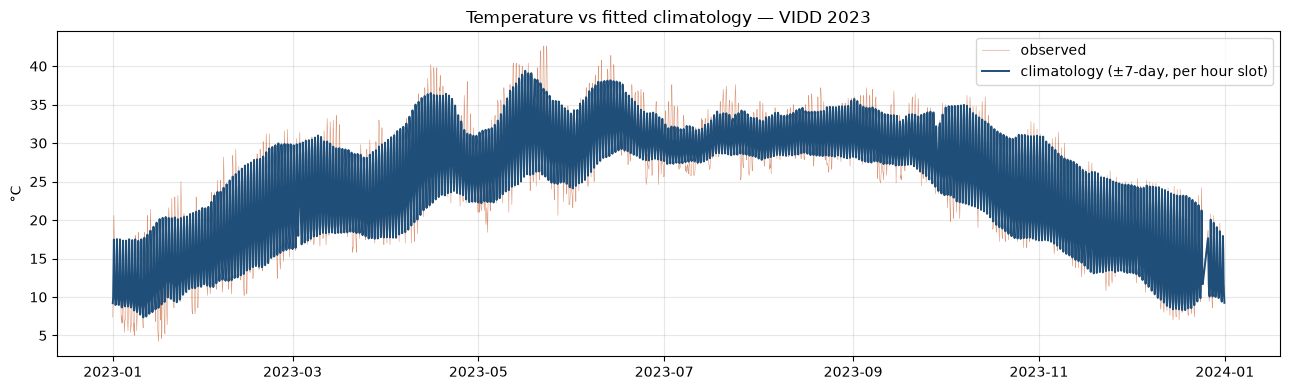

In [8]:
fig, ax = plt.subplots(figsize=(13, 4))
_mu = CLIM["temp_c"]["mean"].reindex(
    pd.MultiIndex.from_arrays(
        [df["time"].dt.normalize(), df["time"].dt.hour.astype("int64")],
        names=["date", "hour"],
    )
).to_numpy()

ax.plot(df["time"], df["temp_c"], lw=0.4, color="#c1440e", alpha=0.55, label="observed")
ax.plot(df["time"], _mu, lw=1.4, color="#1f4e79", label="climatology (±7-day, per hour slot)")
ax.set_title("Temperature vs fitted climatology — VIDD 2023")
ax.set_ylabel("°C"); ax.grid(alpha=0.3); ax.legend()
fig.tight_layout(); plt.show()

## 1.7 Assemble the feature matrix

`build_features()` composes the four steps above and applies an explicit NaN policy. This is the
function Stage 2 re-runs on corrupted data.

**NaN policy — each fill has a reason, none is a blanket `fillna(0)`:**

| Column group | Fill | Why |
|---|---|---|
| `*_step` (gap-masked) | `0.0` | "No valid step information." Steps are centred on zero, so 0 is the *unremarkable* value — it stops data gaps masquerading as faults. |
| `*_roll_med` | the point's own value | Makes the residual 0, i.e. "no local evidence either way". Already applied in 1.5. |
| `*_roll_std` | column median | A sparse window is not evidence of unusual variability; the typical value is the neutral choice. |
| `*_clim_dev` | `0.0` | Zero z-score = "matches the seasonal norm". |

The final assertion is the real guard: Isolation Forest silently rejects NaNs, so the matrix must be
provably complete before Stage 3.

In [9]:
FEATURES = (
    VARS                    # 3  levels
    + STEP_COLS             # 3  gap-aware first differences
    + ROLL_COLS             # 6  24 h rolling median + std
    + RESID_COLS            # 3  value - rolling median
    + CLIM_COLS             # 3  seasonal/diurnal z-score
    + TIME_FEATS            # 4  cyclical hour + day-of-year
)


def build_features(frame, clim):
    """Raw 3-variable frame -> (annotated frame, NaN-free feature matrix)."""
    out = frame.copy()
    out = add_gap_aware_steps(out)
    out = add_time_features(out)
    out = add_rolling_features(out)
    out = add_climatology_features(out, clim)

    for c in STEP_COLS:
        out[c] = out[c].fillna(0.0)
    for v in VARS:
        c = f"{v}_roll_std"
        out[c] = out[c].fillna(out[c].median())
    for c in CLIM_COLS + RESID_COLS:
        out[c] = out[c].fillna(0.0)

    X = out[FEATURES].copy()
    assert not X.isna().any().any(), "feature matrix still contains NaNs"
    assert np.isfinite(X.to_numpy()).all(), "feature matrix contains inf"
    return out, X


df_clean, X_clean = build_features(df, CLIM)

print("feature matrix:", X_clean.shape)
print("NaNs:", int(X_clean.isna().sum().sum()), "| non-finite:", int((~np.isfinite(X_clean.to_numpy())).sum()))
X_clean.head()

feature matrix: (2861, 22)
NaNs: 0 | non-finite: 0


,temp_c,slp_hpa,rh_pct,temp_c_step,slp_hpa_step,rh_pct_step,temp_c_roll_med,slp_hpa_roll_med,rh_pct_roll_med,temp_c_roll_std,slp_hpa_roll_std,rh_pct_roll_std,temp_c_resid,slp_hpa_resid,rh_pct_resid,temp_c_clim_dev,slp_hpa_clim_dev,rh_pct_clim_dev,hour_sin,hour_cos,doy_sin,doy_cos
0,7.4,1019.9,97.300859,0.0,0.0,0.000000,17.6,1019.90,65.247653,5.731666,1.606238,21.627723,-10.2,0.00,32.053206,-0.655311,-0.526187,0.080037,0.000000e+00,1.000000e+00,0.017202,0.999852
1,9.8,1021.9,97.351215,2.4,2.0,0.050356,15.7,1020.45,75.914225,5.139131,1.457395,19.970379,-5.9,1.45,21.436990,-0.005237,-0.329295,0.395010,7.071068e-01,7.071068e-01,0.017202,0.999852
2,17.6,1022.3,65.247653,7.8,0.4,-32.103562,13.8,1021.00,86.580797,4.760152,1.393864,18.762283,3.8,1.30,-21.333144,1.561572,-0.284429,-1.674233,1.000000e+00,6.123234e-17,0.017202,0.999852
3,20.6,1019.0,50.291982,3.0,-3.3,-14.955671,13.1,1020.95,87.385773,4.535259,1.293321,18.080430,7.5,-1.95,-37.093791,1.344663,-0.052879,-1.629223,7.071068e-01,-7.071068e-01,0.017202,0.999852
4,18.0,1018.9,61.955393,-2.6,-0.1,11.663411,13.1,1020.95,87.385773,4.169275,1.253566,17.749073,4.9,-2.05,-25.430380,1.503168,0.013474,-1.437415,1.224647e-16,-1.000000e+00,0.017202,0.999852


### A note on scaling

Isolation Forest splits on one feature at a time using axis-parallel cuts, so it is **invariant to
monotonic rescaling** of individual features — `StandardScaler` is not required and would not change
its output. The matrix is left unscaled here. If Stage 3 adds a distance-based comparison
(LOF, k-NN) or PCA for visualisation, scale at that point.

---
# Stage 2 — Synthetic fault injection

## Why this exists

`candidate_periods.csv` from notebook 01 lists 13 flagged windows, but those are **unverified
candidates, not labelled faults** — several are almost certainly genuine weather (the 4 January
pressure swing is a Western Disturbance; the December temperature/humidity jumps are fog burn-off).
There is no ground truth in this dataset, so Precision/Recall/F1 are undefined without it.

Injecting faults we control creates that ground truth. We know exactly which rows are corrupted,
with what, and how severely.

## The five fault classes

Standard sensor failure modes, each with a distinct signature the feature matrix should expose:

| Fault | Physical cause | Signature | Length |
|---|---|---|---|
| **spike** | transient electrical glitch, telemetry corruption | one huge `*_resid` / `*_step` | 1 obs |
| **stuck_at** | frozen ADC, iced-over sensor, dead serial link | `*_roll_std` collapses to ~0 | 8–14 obs (1–2 days) |
| **bias** | miscalibration, radiation shield failure | sustained `*_clim_dev` offset, normal local dynamics | 8–16 obs (1–2 days) |
| **drift** | ageing element, slow fouling | `*_clim_dev` ramps; each individual step stays small | 12–20 obs (1.5–2.5 days) |
| **noise_burst** | loose connection, EMI, failing power supply | `*_roll_std` inflates | 8–14 obs |

`stuck_at` is worth highlighting: notebook 01 found **zero** natural flat runs of ≥8 readings, so the
baseline rate is exactly 0 and any detection is unambiguous.

`drift` is the hard case — no single reading looks wrong, and the per-step differences stay within
normal range. It is the fault class most likely to defeat Isolation Forest, and the main reason the
plan holds a regression-residual stage in reserve.

## Design rules

1. **The clean data is never mutated.** Injection works on a deep copy; `df` and `X_clean` are
   re-verified as untouched at the end.
2. **Episodes never overlap** — a global occupancy mask keeps every corrupted row attributable to
   exactly one `(fault_type, variable)` pair. Without this, per-fault-type recall in Stage 3 would be
   ambiguous.
3. **Magnitudes are per-variable and physical**, not "n sigma". A 5 °C bias and a 5 hPa bias are
   different beasts; hard-coding units keeps the faults defensible to a judge.
4. **Seeded RNG** (`SEED = 42`) so the labels are reproducible across reruns.
5. **`rh_pct` is clipped to [0, 100]** after injection, because a real humidity sensor saturates.
   This can partially mask an RH fault near saturation — a diagnostic below measures exactly how
   often that happens rather than leaving it as a hidden assumption.

In [10]:
# Per-variable fault magnitudes, in the variable's own physical units.
MAGNITUDE = {
    "temp_c":  {"spike": (8.0, 20.0), "bias": (3.0, 8.0),   "drift": (4.0, 10.0),  "noise": (2.0, 5.0)},
    "slp_hpa": {"spike": (10.0, 25.0), "bias": (3.0, 8.0),  "drift": (4.0, 10.0),  "noise": (2.0, 5.0)},
    "rh_pct":  {"spike": (30.0, 60.0), "bias": (10.0, 25.0), "drift": (15.0, 35.0), "noise": (8.0, 15.0)},
}

# episodes per variable, and episode length in observations (3 h each)
PLAN = {
    "spike":       {"n_per_var": 5, "len": (1, 1)},
    "stuck_at":    {"n_per_var": 1, "len": (8, 14)},
    "bias":        {"n_per_var": 1, "len": (8, 16)},
    "drift":       {"n_per_var": 1, "len": (12, 20)},
    "noise_burst": {"n_per_var": 1, "len": (8, 14)},
}

PHYSICAL_LIMITS = {"rh_pct": (0.0, 100.0)}   # humidity sensors saturate
EDGE_MARGIN = 8                              # keep episodes clear of the series ends

### The injector

Each episode picks a non-overlapping window, corrupts one variable inside it, and writes four
ground-truth columns.

In [11]:
def inject_faults(frame, plan=PLAN, seed=SEED):
    """Return (corrupted copy, labels frame, episode log). `frame` is not modified."""
    rng = np.random.default_rng(seed)
    out = frame.copy(deep=True)
    n = len(out)

    labels = pd.DataFrame({
        "is_fault": np.zeros(n, dtype=int),
        "fault_type": np.array(["none"] * n, dtype=object),
        "fault_var": np.array(["none"] * n, dtype=object),
        "episode_id": np.full(n, -1, dtype=int),
    })

    occupied = np.zeros(n, dtype=bool)
    episodes = []

    def reserve(length):
        """Find a free window of `length` rows; None if the series is too crowded."""
        for _ in range(500):
            start = int(rng.integers(EDGE_MARGIN, n - length - EDGE_MARGIN))
            sl = slice(start, start + length)
            if not occupied[sl].any():
                occupied[sl] = True
                return sl
        return None

    ep_id = 0
    for ftype, spec in plan.items():
        for var in VARS:
            for _ in range(spec["n_per_var"]):
                length = int(rng.integers(spec["len"][0], spec["len"][1] + 1))
                sl = reserve(length)
                if sl is None:
                    print(f"  ! no free window for {ftype}/{var}, skipped")
                    continue

                vals = out[var].to_numpy(copy=True)
                sign = float(rng.choice([-1.0, 1.0]))
                mag = MAGNITUDE[var]

                if ftype == "spike":
                    amount = sign * rng.uniform(*mag["spike"])
                    vals[sl] += amount
                    detail = f"{amount:+.1f} single-point"

                elif ftype == "stuck_at":
                    held = vals[sl.start - 1]
                    vals[sl] = held
                    detail = f"held at {held:.1f} for {length} obs"

                elif ftype == "bias":
                    amount = sign * rng.uniform(*mag["bias"])
                    vals[sl] += amount
                    detail = f"{amount:+.1f} offset for {length} obs"

                elif ftype == "drift":
                    amount = sign * rng.uniform(*mag["drift"])
                    # Start one increment in, not at exactly 0.0 - otherwise the first
                    # row of every drift is labelled faulty while being bit-identical
                    # to the clean value, i.e. an unlearnable positive.
                    vals[sl] += np.linspace(amount / length, amount, length)
                    detail = f"ramp -> {amount:+.1f} over {length} obs"

                elif ftype == "noise_burst":
                    sigma = rng.uniform(*mag["noise"])
                    vals[sl] += rng.normal(0.0, sigma, size=length)
                    detail = f"added N(0, {sigma:.1f}) for {length} obs"

                else:
                    raise ValueError(ftype)

                if var in PHYSICAL_LIMITS:
                    lo, hi = PHYSICAL_LIMITS[var]
                    vals = np.clip(vals, lo, hi)

                out[var] = vals
                # NOTE: .iloc, not .loc. On a RangeIndex, `labels.loc[slice(a, b)]` is
                # LABEL-based and includes row b, while the numpy write `vals[sl]` is
                # end-exclusive - so .loc would label one extra, uncorrupted row per
                # episode and quietly cap precision in Stage 3.
                labels.iloc[sl, labels.columns.get_loc("is_fault")] = 1
                labels.iloc[sl, labels.columns.get_loc("fault_type")] = ftype
                labels.iloc[sl, labels.columns.get_loc("fault_var")] = var
                labels.iloc[sl, labels.columns.get_loc("episode_id")] = ep_id

                episodes.append({
                    "episode_id": ep_id,
                    "fault_type": ftype,
                    "variable": var,
                    "start": out["time"].iloc[sl.start],
                    "end": out["time"].iloc[sl.stop - 1],
                    "n_obs": length,
                    "detail": detail,
                })
                ep_id += 1

    return out, labels, pd.DataFrame(episodes)


# Snapshot the clean values so we can prove afterwards that they were not mutated.
CLEAN_SNAPSHOT = df[VARS].copy(deep=True)

df_faulty_raw, labels, episodes = inject_faults(df)

print("episodes injected:", len(episodes))
print("rows labelled as faulty:", int(labels["is_fault"].sum()),
      "(%.2f%% of %d)" % (100 * labels["is_fault"].mean(), len(labels)))

episodes injected: 27
rows labelled as faulty: 179 (6.26% of 2861)


### Verify the injection did what it claims

Three checks, because a silently no-op injector would produce labels the model can never learn and
metrics that look like a modelling failure rather than a data-generation bug:

1. The clean frame is bit-identical to before injection.
2. Every labelled row actually changed value — this is where RH clipping would show up.
3. No unlabelled row changed.

In [12]:
# 1 - the clean frame must be bit-identical to its pre-injection snapshot
pd.testing.assert_frame_equal(df[VARS], CLEAN_SNAPSHOT, obj="clean data after injection")
print("clean frame unmodified by inject_faults() - confirmed")

changed = np.zeros(len(df), dtype=bool)
for v in VARS:
    changed |= ~np.isclose(df[v].to_numpy(), df_faulty_raw[v].to_numpy(),
                           rtol=0, atol=1e-9, equal_nan=True)

lab = labels["is_fault"].to_numpy().astype(bool)

print("labelled rows            :", int(lab.sum()))
print("labelled AND changed     :", int((lab & changed).sum()))
print("labelled but NOT changed :", int((lab & ~changed).sum()), " <- RH clipping / stuck-at no-ops")
print("changed but NOT labelled :", int((~lab & changed).sum()), " <- must be 0")

assert (~lab & changed).sum() == 0, "corruption leaked outside a labelled window"

eff = (lab & changed).sum() / max(lab.sum(), 1)
print("\neffective corruption rate: %.1f%% of labelled rows carry a real value change" % (100 * eff))

clean frame unmodified by inject_faults() - confirmed
labelled rows            : 179
labelled AND changed     : 178
labelled but NOT changed : 1  <- RH clipping / stuck-at no-ops
changed but NOT labelled : 0  <- must be 0

effective corruption rate: 99.4% of labelled rows carry a real value change


### Rebuild features on the corrupted series

The same `build_features()` from Stage 1, with the **clean-fitted climatology** — so the injected
faults are measured against the fault-free seasonal norm rather than against themselves.

In [13]:
df_faulty, X_faulty = build_features(df_faulty_raw, CLIM)

# Attach ground truth alongside the features (never inside them).
df_faulty = pd.concat([df_faulty, labels], axis=1)

y = df_faulty["is_fault"].to_numpy()

print("X_faulty:", X_faulty.shape, "| y:", y.shape, "| positives:", int(y.sum()))
assert list(X_faulty.columns) == FEATURES
assert not set(FEATURES) & set(labels.columns), "label leaked into the feature matrix"
print("no label leakage into features - confirmed")

X_faulty: (2861, 22) | y: (2861,) | positives: 179
no label leakage into features - confirmed


### Do the features respond to the faults?

The point of Stage 1 was to make faults *visible*. A quick separation check: compare the mean absolute
value of a few key features on clean vs faulty rows. Large ratios mean the feature carries signal;
ratios near 1.0 mean that fault class is nearly invisible and will be hard for Stage 3.

In [14]:
# Each episode corrupts exactly ONE variable, so we must compare a fault against the
# feature belonging to *that* variable. Averaging temp/slp/rh features over all rows of a
# fault type would dilute every ratio toward 1.0 and hide real signal.
KINDS = ["step", "resid", "roll_std", "clim_dev"]
clean_m = df_faulty["fault_type"].eq("none").to_numpy()
rows = []

for ftype in ["spike", "stuck_at", "bias", "drift", "noise_burst"]:
    all_m = df_faulty["fault_type"].eq(ftype)
    rec = {"fault_type": ftype, "n_rows": int(all_m.sum())}
    for kind in KINDS:
        ratios = []
        for v in VARS:
            m = (all_m & df_faulty["fault_var"].eq(v)).to_numpy()
            if m.sum() == 0:
                continue
            f = f"{v}_{kind}"
            a = X_faulty.loc[m, f].abs().mean()
            b = X_faulty.loc[clean_m, f].abs().mean()
            if b > 1e-9:
                ratios.append(a / b)
        rec[kind] = round(float(np.mean(ratios)), 2) if ratios else np.nan
    rows.append(rec)

sep = pd.DataFrame(rows).set_index("fault_type")
print("mean |feature| on faulty rows / on clean rows, corrupted variable only")
print("1.0 = no signal;  >1 = fault inflates the feature;  <1 = fault suppresses it\n")
print(sep.to_string())
print("\nReading it:")
print("  spike       -> resid/step should spike hard")
print("  stuck_at    -> roll_std should fall WELL BELOW 1.0 (variability collapses);")
print("                 a low ratio here is strong signal, not absence of it")
print("  bias/drift  -> clim_dev carries the signal; step/resid stay near 1.0 by design")
print("  noise_burst -> roll_std should rise")

mean |feature| on faulty rows / on clean rows, corrupted variable only
1.0 = no signal;  >1 = fault inflates the feature;  <1 = fault suppresses it

             n_rows  step  resid  roll_std  clim_dev
fault_type                                          
spike            15  7.26   7.86      2.34      8.70
stuck_at         42  0.00   0.00      0.19      2.46
bias             36  1.07   0.97      1.27      6.46
drift            51  0.86   0.95      1.05      3.09
noise_burst      35  1.56   1.41      1.28      1.93

Reading it:
  spike       -> resid/step should spike hard
  stuck_at    -> roll_std should fall WELL BELOW 1.0 (variability collapses);
                 a low ratio here is strong signal, not absence of it
  bias/drift  -> clim_dev carries the signal; step/resid stay near 1.0 by design
  noise_burst -> roll_std should rise


### Visual check — one episode per fault class

Clean series in grey, corrupted in red, with the labelled window shaded. If a panel looks identical
in both colours, that fault is not being injected effectively.

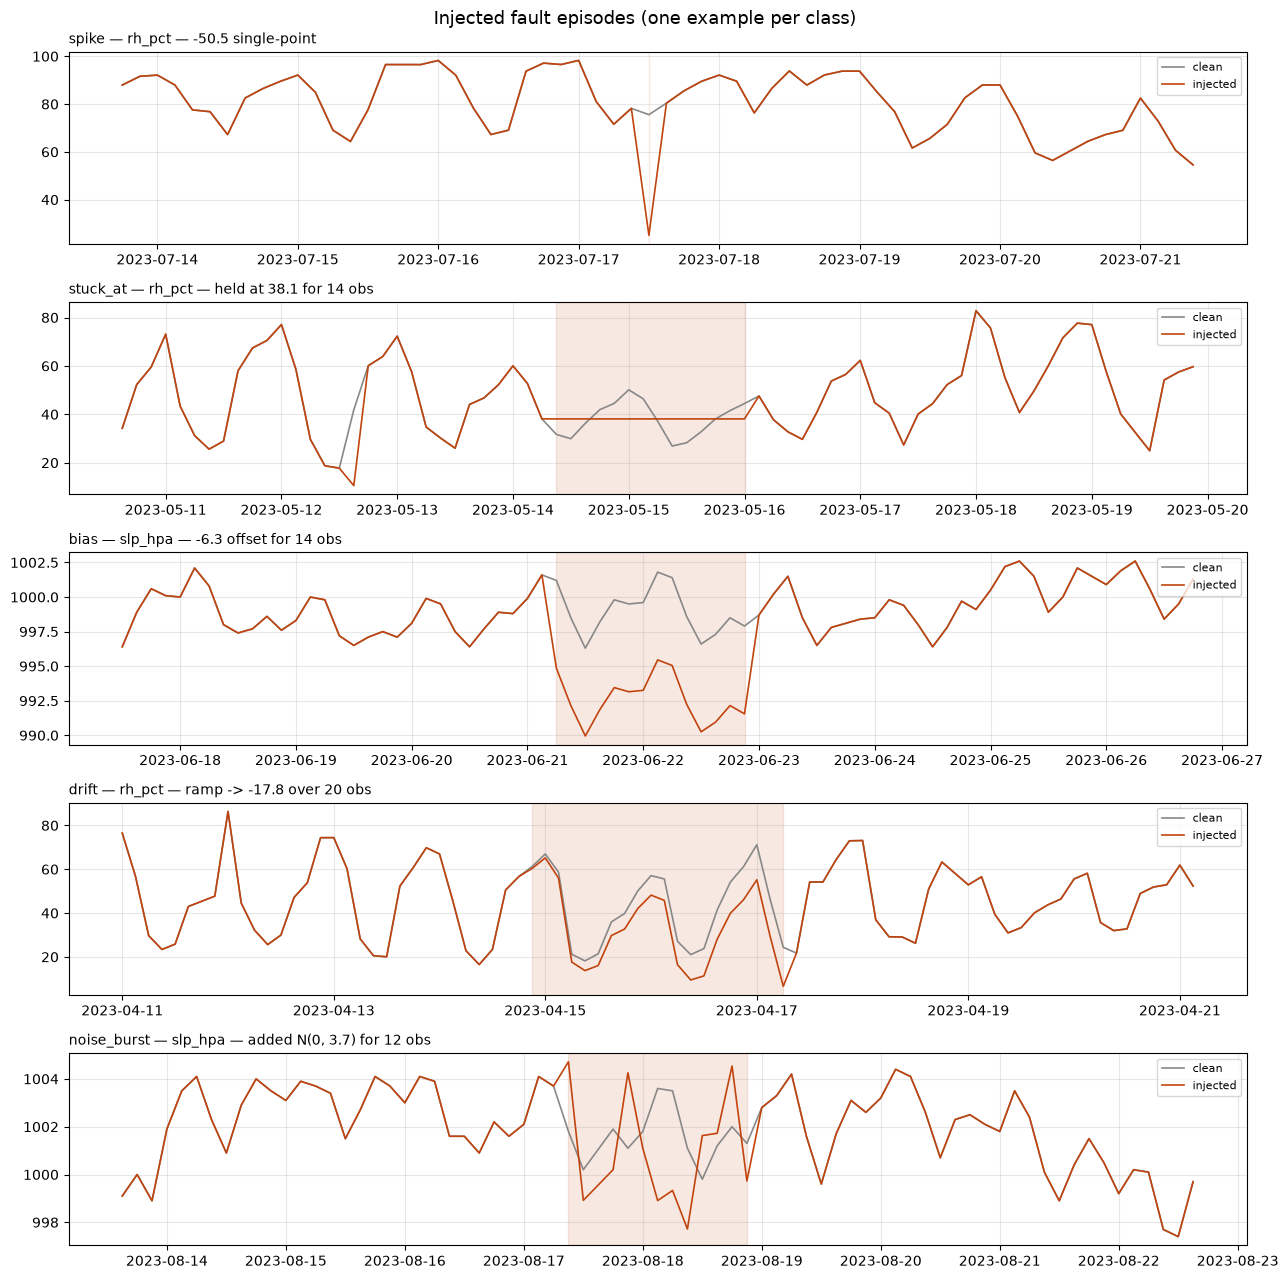

In [15]:
show = (episodes.sort_values("n_obs", ascending=False)
        .drop_duplicates("fault_type")
        .set_index("fault_type")
        .reindex(["spike", "stuck_at", "bias", "drift", "noise_burst"]))

fig, axes = plt.subplots(5, 1, figsize=(13, 13))
for ax, (ftype, ep) in zip(axes, show.iterrows()):
    v = ep["variable"]
    i0 = df_faulty.index[df_faulty["time"] == ep["start"]][0]
    i1 = df_faulty.index[df_faulty["time"] == ep["end"]][0]
    lo, hi = max(0, i0 - 30), min(len(df_faulty), i1 + 31)
    w = slice(lo, hi)

    ax.plot(df["time"].iloc[w], df[v].iloc[w], lw=1.2, color="#888", label="clean")
    ax.plot(df_faulty["time"].iloc[w], df_faulty[v].iloc[w], lw=1.2, color="#c1440e", label="injected")
    ax.axvspan(ep["start"], ep["end"], color="#c1440e", alpha=0.12)
    ax.set_title(f"{ftype} — {v} — {ep['detail']}", fontsize=10, loc="left")
    ax.grid(alpha=0.3); ax.legend(fontsize=8, loc="upper right")

fig.suptitle("Injected fault episodes (one example per class)", fontsize=13)
fig.tight_layout(); plt.show()

---
# Summary — Stage 1 & 2 output

In [16]:
line = "=" * 74

print(line); print("FINAL FEATURE LIST".center(74)); print(line)
groups = [
    ("levels", VARS),
    ("gap-aware steps", STEP_COLS),
    ("24 h rolling median/std", ROLL_COLS),
    ("residual (value - roll_med)", RESID_COLS),
    ("climatology deviation (z)", CLIM_COLS),
    ("cyclical time", TIME_FEATS),
]
i = 1
for name, cols in groups:
    print(f"\n  {name}  [{len(cols)}]")
    for c in cols:
        print(f"    {i:2d}. {c}")
        i += 1
print(f"\n  TOTAL FEATURES: {len(FEATURES)}")

print("\n" + line); print("DATASET SHAPES".center(74)); print(line)
print(f"  source CSV                     : {raw.shape[0]} rows x {raw.shape[1]} cols")
print(f"  after pruning / imputation     : {df.shape[0]} rows")
print(f"  X_clean  (fault-free reference): {X_clean.shape[0]} rows x {X_clean.shape[1]} features")
print(f"  X_faulty (Stage 3 input)       : {X_faulty.shape[0]} rows x {X_faulty.shape[1]} features")
print(f"  y        (ground truth)        : {y.shape[0]} labels")
print(f"  time span                      : {df['time'].min()}  ->  {df['time'].max()}")

print("\n" + line); print("INJECTED FAULTS".center(74)); print(line)
n_pos = int(labels["is_fault"].sum())
print(f"  episodes injected     : {len(episodes)}")
print(f"  faulty rows (label=1) : {n_pos}")
print(f"  clean rows  (label=0) : {len(labels) - n_pos}")
print(f"  contamination rate    : {n_pos / len(labels):.4f}  ({100 * n_pos / len(labels):.2f}%)")
print("  -> use this value for IsolationForest(contamination=...) in Stage 3")

print("\n" + line); print("FAULT COUNTS BY TYPE".center(74)); print(line)
by_type = (df_faulty[df_faulty["is_fault"] == 1]
           .groupby("fault_type")
           .agg(episodes=("episode_id", "nunique"), rows=("is_fault", "size")))
by_type["pct_of_all_rows"] = (100 * by_type["rows"] / len(df_faulty)).round(2)
print(by_type.to_string())

print("\n" + line); print("FAULT COUNTS BY VARIABLE".center(74)); print(line)
print(df_faulty[df_faulty["is_fault"] == 1]
      .groupby("fault_var")
      .agg(episodes=("episode_id", "nunique"), rows=("is_fault", "size")).to_string())

print("\n" + line); print("TYPE x VARIABLE (rows)".center(74)); print(line)
print(pd.crosstab(df_faulty.loc[df_faulty["is_fault"] == 1, "fault_type"],
                  df_faulty.loc[df_faulty["is_fault"] == 1, "fault_var"]).to_string())

                            FINAL FEATURE LIST                            

  levels  [3]
     1. temp_c
     2. slp_hpa
     3. rh_pct

  gap-aware steps  [3]
     4. temp_c_step
     5. slp_hpa_step
     6. rh_pct_step

  24 h rolling median/std  [6]
     7. temp_c_roll_med
     8. slp_hpa_roll_med
     9. rh_pct_roll_med
    10. temp_c_roll_std
    11. slp_hpa_roll_std
    12. rh_pct_roll_std

  residual (value - roll_med)  [3]
    13. temp_c_resid
    14. slp_hpa_resid
    15. rh_pct_resid

  climatology deviation (z)  [3]
    16. temp_c_clim_dev
    17. slp_hpa_clim_dev
    18. rh_pct_clim_dev

  cyclical time  [4]
    19. hour_sin
    20. hour_cos
    21. doy_sin
    22. doy_cos

  TOTAL FEATURES: 22

                              DATASET SHAPES                              
  source CSV                     : 2861 rows x 13 cols
  after pruning / imputation     : 2861 rows
  X_clean  (fault-free reference): 2861 rows x 22 features
  X_faulty (Stage 3 input)       : 2861 rows x 22

### Episode log

Every injected episode, with its exact window and magnitude — the auditable record behind the labels.

In [17]:
episodes.sort_values("start").reset_index(drop=True)

,episode_id,fault_type,variable,start,end,n_obs,detail
0,11,spike,rh_pct,2023-01-26 12:00:00,2023-01-26 12:00:00,1,+56.8 single-point
1,0,spike,temp_c,2023-02-03 00:00:00,2023-02-03 00:00:00,1,+13.3 single-point
2,8,spike,slp_hpa,2023-02-04 03:00:00,2023-02-04 03:00:00,1,+11.0 single-point
3,10,spike,rh_pct,2023-03-02 00:00:00,2023-03-02 00:00:00,1,+40.6 single-point
4,2,spike,temp_c,2023-03-15 06:00:00,2023-03-15 06:00:00,1,-19.7 single-point
5,23,drift,rh_pct,2023-04-14 21:00:00,2023-04-17 06:00:00,20,ramp -> -17.8 over 20 obs
6,13,spike,rh_pct,2023-05-12 15:00:00,2023-05-12 15:00:00,1,-31.3 single-point
7,17,stuck_at,rh_pct,2023-05-14 09:00:00,2023-05-16 00:00:00,14,held at 38.1 for 14 obs
8,16,stuck_at,slp_hpa,2023-05-28 21:00:00,2023-05-30 12:00:00,14,held at 1009.0 for 14 obs
9,1,spike,temp_c,2023-06-06 18:00:00,2023-06-06 18:00:00,1,+16.4 single-point


---
## State handed to Stage 3

| Object | Contents |
|---|---|
| `X_clean` | fault-free feature matrix — reference |
| `X_faulty` | same features on the corrupted series — **the Stage 3 input** |
| `y` | binary ground truth aligned to `X_faulty` |
| `df_faulty` | features + `is_fault`, `fault_type`, `fault_var`, `episode_id` |
| `episodes` | one row per injected episode (window, variable, magnitude) |
| `CLIM` | climatology fitted on clean data |
| `build_features` | the reusable Stage 1 pipeline |

`01_dataset_eda.ipynb` and `data/raw/` are untouched.

---
# Stage 3 — Isolation Forest

## Experimental protocol

The discipline that makes this result trustworthy rather than merely favourable:

1. **Features only.** The model sees `X_faulty[FEATURES]` — 22 numeric columns. `is_fault`,
   `fault_type`, `fault_var` and `episode_id` live in `df_faulty` and are asserted out of the matrix
   before fitting.
2. **Labels are evaluation-only.** Isolation Forest is unsupervised; `y` is never passed to `fit()`.
   The assertion below makes that structural rather than a matter of trust.
3. **Chronological split, never shuffled.** Rows are ordered in time and adjacent observations are
   heavily autocorrelated — a random split would put 03:00 in train and 06:00 of the same day in
   test, leaking the answer through the rolling and climatology features. Train = first 70 % of the
   year, test = last 30 %, cut at a real timestamp.
4. **Fit on the training portion only**, then score train and test separately.
5. **Trained on contaminated data.** The training slice still contains its share of injected faults.
   That is the honest deployment scenario: nobody hands you a certified-clean year to fit on.

## A note on what the split can and cannot tell us

The chronological split is methodologically correct, but it puts only ~30 % of the episodes in the
test window — and with 3 episodes per fault class in the whole year, some classes will land in test
with one episode or none. Test-set per-class recall is therefore **directionally useful but
statistically thin**.

So this notebook reports per-class recall on **both** the test set and the full series, clearly
separated. The full-series numbers are legitimate — the labels never influenced fitting, so scoring
the whole year introduces no label leakage — and they are the ones with enough support to be worth
reading. The test-set numbers remain the honest headline for generalisation.

In [18]:
from sklearn.ensemble import IsolationForest
from sklearn.metrics import (precision_recall_fscore_support, confusion_matrix,
                             precision_score, recall_score, f1_score,
                             average_precision_score, roc_auc_score)

RANDOM_STATE = 42
N_ESTIMATORS = 200
TRAIN_FRAC = 0.70

# --- guard: no label may reach the model -------------------------------------
LABEL_COLS = ["is_fault", "fault_type", "fault_var", "episode_id"]
assert not set(FEATURES) & set(LABEL_COLS), "label column present in FEATURES"
assert list(X_faulty.columns) == FEATURES
assert X_faulty.select_dtypes(exclude=[np.number]).empty, "non-numeric column in feature matrix"
print("label-leakage guard passed -", len(FEATURES), "numeric features, 0 label columns")

# --- chronological split ------------------------------------------------------
n = len(X_faulty)
split_i = int(TRAIN_FRAC * n)
split_time = df_faulty["time"].iloc[split_i]

is_train = np.zeros(n, dtype=bool)
is_train[:split_i] = True
is_test = ~is_train

X_train, X_test = X_faulty.iloc[:split_i], X_faulty.iloc[split_i:]
y_train, y_test = y[:split_i], y[split_i:]

print(f"\nsplit at {split_time}  (chronological, no shuffling)")
print(f"  train : {len(X_train):5d} rows  {df_faulty['time'].iloc[0]}  ->  {df_faulty['time'].iloc[split_i-1]}"
      f"   faults {int(y_train.sum()):3d}  ({100*y_train.mean():.2f}%)")
print(f"  test  : {len(X_test):5d} rows  {split_time}  ->  {df_faulty['time'].iloc[-1]}"
      f"   faults {int(y_test.sum()):3d}  ({100*y_test.mean():.2f}%)")

label-leakage guard passed - 22 numeric features, 0 label columns

split at 2023-09-11 09:00:00  (chronological, no shuffling)
  train :  2002 rows  2023-01-01 00:00:00  ->  2023-09-11 06:00:00   faults 125  (6.24%)
  test  :   859 rows  2023-09-11 09:00:00  ->  2023-12-31 21:00:00   faults  54  (6.29%)


### Contamination

`contamination` tells Isolation Forest what fraction of the training data to place outside the
decision boundary — it sets the alarm budget, not the model's ranking.

We set it to the **actual injected fault rate in the training slice**, because that is the data the
model is fitted on. This is a deliberately generous, oracle-informed choice: in production you would
not know the true rate and would have to pick it from an alarm budget or a validation sweep. Stating
that plainly matters — an unstated oracle assumption is how prototypes quietly overstate themselves.

In [19]:
CONTAMINATION = float(y_train.mean())

print("injected fault rate")
print(f"  training slice (used for contamination) : {CONTAMINATION:.4f}  ({100*CONTAMINATION:.2f}%)")
print(f"  test slice                              : {y_test.mean():.4f}  ({100*y_test.mean():.2f}%)")
print(f"  full series                             : {y.mean():.4f}  ({100*y.mean():.2f}%)")
print("\n-> contamination = %.4f (oracle-informed; see note above)" % CONTAMINATION)

injected fault rate
  training slice (used for contamination) : 0.0624  (6.24%)
  test slice                              : 0.0629  (6.29%)
  full series                             : 0.0626  (6.26%)

-> contamination = 0.0624 (oracle-informed; see note above)


### Fit

No feature scaling: Isolation Forest makes axis-parallel cuts on one feature at a time and is
invariant to monotonic rescaling, so a `StandardScaler` would change nothing.

In [20]:
iforest = IsolationForest(
    n_estimators=N_ESTIMATORS,
    contamination=CONTAMINATION,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
iforest.fit(X_train)          # y is NOT passed - unsupervised

# Higher score = more anomalous. sklearn flags a point when decision_function < 0.
score_all = -iforest.score_samples(X_faulty)
THRESHOLD = -iforest.offset_
pred_all = (score_all > THRESHOLD).astype(int)

df_faulty["if_score"] = score_all
df_faulty["if_pred"] = pred_all

assert (pred_all == (iforest.predict(X_faulty) == -1).astype(int)).all(), "threshold != sklearn predict"
print("fitted:", iforest)
print(f"\ndecision threshold: {THRESHOLD:.4f}")
print(f"flagged  train {pred_all[is_train].sum():4d} / {is_train.sum()}"
      f"   test {pred_all[is_test].sum():4d} / {is_test.sum()}"
      f"   full {pred_all.sum():4d} / {n}")

fitted: IsolationForest(contamination=0.06243756243756244, n_estimators=200, n_jobs=-1,
                random_state=42)

decision threshold: 0.5136
flagged  train  125 / 2002   test  155 / 859   full  280 / 2861


## Overall metrics

Precision / recall / F1 for the positive (fault) class, plus the confusion matrix and the anomaly
rate — the fraction of rows the detector actually alarms on, which is the operational cost figure.

In [21]:
def evaluate(y_true, y_pred, scores=None, label=""):
    p, r, f, _ = precision_recall_fscore_support(
        y_true, y_pred, average="binary", pos_label=1, zero_division=0)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    rec = {
        "scope": label, "n_rows": len(y_true), "n_faults": int(y_true.sum()),
        "precision": p, "recall": r, "f1": f,
        "tp": int(tp), "fp": int(fp), "fn": int(fn), "tn": int(tn),
        "n_flagged": int(y_pred.sum()), "anomaly_rate": float(y_pred.mean()),
    }
    if scores is not None and 0 < y_true.sum() < len(y_true):
        rec["avg_precision"] = average_precision_score(y_true, scores)
        rec["roc_auc"] = roc_auc_score(y_true, scores)
    return rec


overall = pd.DataFrame([
    evaluate(y_train, pred_all[is_train], score_all[is_train], "train"),
    evaluate(y_test,  pred_all[is_test],  score_all[is_test],  "test"),
    evaluate(y,       pred_all,           score_all,           "full series"),
]).set_index("scope")

print("ISOLATION FOREST - OVERALL\n")
print(overall[["n_rows", "n_faults", "precision", "recall", "f1",
               "anomaly_rate", "avg_precision", "roc_auc"]].round(4).to_string())
print("\nconfusion matrices (rows = actual, cols = predicted)\n")
for scope, m, yp in [("train", y_train, pred_all[is_train]),
                     ("test", y_test, pred_all[is_test]),
                     ("full series", y, pred_all)]:
    cm = confusion_matrix(m, yp, labels=[0, 1])
    print(f"  {scope}")
    print("            pred_clean  pred_fault")
    print(f"    clean   {cm[0,0]:10d}  {cm[0,1]:10d}")
    print(f"    fault   {cm[1,0]:10d}  {cm[1,1]:10d}\n")

ISOLATION FOREST - OVERALL

             n_rows  n_faults  precision  recall      f1  anomaly_rate  avg_precision  roc_auc
scope                                                                                         
train          2002       125     0.2160  0.2160  0.2160        0.0624         0.2097   0.7593
test            859        54     0.0710  0.2037  0.1053        0.1804         0.0992   0.5362
full series    2861       179     0.1357  0.2123  0.1656        0.0979         0.1417   0.6990

confusion matrices (rows = actual, cols = predicted)

  train
            pred_clean  pred_fault
    clean         1779          98
    fault           98          27

  test
            pred_clean  pred_fault
    clean          661         144
    fault           43          11

  full series
            pred_clean  pred_fault
    clean         2440         242
    fault          141          38



## Per-fault-type recall

Precision is undefined per fault type — a false positive belongs to no class — so this table reports
**recall** (what fraction of each fault's rows were caught) plus two extra columns that matter more
than row recall for an operational system:

* **`episodes`** / **`ep_detected`** — an episode counts as detected if *at least one* of its rows is
  flagged. Catching 3 rows of a 20-row drift still raises the alarm; a maintenance crew gets
  dispatched either way. Row recall understates operational usefulness for long faults.
* **`mean_score`** — the mean anomaly score for that class against the clean-row baseline, showing
  whether a missed class is *near* the threshold or nowhere near it.

In [22]:
def per_type_table(mask, name):
    sub = df_faulty[mask]
    clean_mean = sub.loc[sub["fault_type"].eq("none"), "if_score"].mean()
    rows = []
    for ftype in ["spike", "stuck_at", "bias", "drift", "noise_burst"]:
        m = sub["fault_type"].eq(ftype)
        if m.sum() == 0:
            rows.append({"fault_type": ftype, "rows": 0, "recall": np.nan,
                         "episodes": 0, "ep_detected": 0, "ep_recall": np.nan,
                         "mean_score": np.nan})
            continue
        g = sub[m]
        ep = g.groupby("episode_id")["if_pred"].max()
        rows.append({
            "fault_type": ftype,
            "rows": int(m.sum()),
            "caught": int(g["if_pred"].sum()),
            "recall": float(g["if_pred"].mean()),
            "episodes": int(ep.size),
            "ep_detected": int(ep.sum()),
            "ep_recall": float(ep.mean()),
            "mean_score": float(g["if_score"].mean()),
        })
    t = pd.DataFrame(rows).set_index("fault_type")
    t.attrs["clean_mean_score"] = clean_mean
    print(f"--- {name} ---   (clean-row mean score = {clean_mean:.4f})")
    print(t.round(4).to_string(), "\n")
    return t


print("PER-FAULT-TYPE RECALL\n")
per_type_full = per_type_table(np.ones(n, dtype=bool), "FULL SERIES (primary - full support)")
per_type_test = per_type_table(is_test, "TEST SET ONLY (thin support, see protocol note)")

PER-FAULT-TYPE RECALL

--- FULL SERIES (primary - full support) ---   (clean-row mean score = 0.4683)
             rows  caught  recall  episodes  ep_detected  ep_recall  mean_score
fault_type                                                                     
spike          15      13  0.8667        15           13     0.8667      0.5559
stuck_at       42       0  0.0000         3            0     0.0000      0.4785
bias           36       9  0.2500         3            3     1.0000      0.5004
drift          51      11  0.2157         3            2     0.6667      0.4950
noise_burst    35       5  0.1429         3            1     0.3333      0.4691 

--- TEST SET ONLY (thin support, see protocol note) ---   (clean-row mean score = 0.4903)
             rows  caught  recall  episodes  ep_detected  ep_recall  mean_score
fault_type                                                                     
spike           3       3  1.0000         3            3        1.0      0.5866
stuck_

## Baseline — the rule-based detectors from notebook 01

Isolation Forest is only worth the complexity if it beats the simple thing. Notebook 01 contained two
rules, re-implemented here and scored on the **same synthetic labels**:

* **flat-run** — flag any run of ≥ 8 identical consecutive values. Used verbatim, no tuning; it found
  zero natural flat runs in the clean data, so it is a purpose-built stuck-at detector.
* **step threshold** — notebook 01 only printed the *top-3* largest changes per variable, which is a
  ranking, not a detector. To turn it into one we z-normalise each gap-aware step and flag rows above
  a threshold, **calibrated to raise the same number of alarms as Isolation Forest**. Equal alarm
  budget is what makes the precision comparison fair; giving the baseline a different budget would
  rig the result either way.
* **combined** — flat-run OR step, i.e. the full notebook-01 rule set.

In [23]:
def flat_run_flags(frame, cols, min_len=8):
    flag = np.zeros(len(frame), dtype=bool)
    for c in cols:
        s = frame[c]
        run_id = s.ne(s.shift()).cumsum()
        size = s.groupby(run_id).transform("size")
        flag |= (size >= min_len).to_numpy() & s.notna().to_numpy()
    return flag


# --- baseline 1: flat runs (notebook 01 rule, untuned) ---
base_flat = flat_run_flags(df_faulty_raw, VARS, min_len=8).astype(int)

# --- baseline 2: step magnitude, calibrated to the same alarm budget as IF ---
step_z = (X_faulty[STEP_COLS] / X_faulty[STEP_COLS].std()).abs().max(axis=1).to_numpy()
budget = pred_all.sum() / n
step_cut = np.quantile(step_z, 1.0 - budget)
base_step = (step_z > step_cut).astype(int)

# --- baseline 3: notebook 01 rule set = flat-run OR step ---
base_comb = ((base_flat + base_step) > 0).astype(int)

for nm, arr in [("flat_run", base_flat), ("step", base_step), ("combined", base_comb)]:
    df_faulty[f"base_{nm}"] = arr

print(f"alarm budget matched to IF: {budget:.4f}  (step z cut = {step_cut:.3f})\n")

baseline_rows = []
for nm, arr in [("isolation_forest", pred_all), ("rule_flat_run", base_flat),
                ("rule_step", base_step), ("rule_combined", base_comb)]:
    for scope, m in [("test", is_test), ("full series", np.ones(n, dtype=bool))]:
        rec = evaluate(y[m], arr[m], None, scope)
        rec["model"] = nm
        baseline_rows.append(rec)

comparison = (pd.DataFrame(baseline_rows)
              .set_index(["scope", "model"])
              [["n_faults", "precision", "recall", "f1", "n_flagged", "anomaly_rate"]]
              .round(4))
print("MODEL vs RULE BASELINES (same labels, same alarm budget)\n")
print(comparison.to_string())

alarm budget matched to IF: 0.0979  (step z cut = 1.976)

MODEL vs RULE BASELINES (same labels, same alarm budget)

                              n_faults  precision  recall      f1  n_flagged  anomaly_rate
scope       model                                                                         
test        isolation_forest        54     0.0710  0.2037  0.1053        155        0.1804
full series isolation_forest       179     0.1357  0.2123  0.1656        280        0.0979
test        rule_flat_run           54     0.9333  0.2593  0.4058         15        0.0175
full series rule_flat_run          179     0.9333  0.2346  0.3750         45        0.0157
test        rule_step               54     0.0561  0.1111  0.0745        107        0.1246
full series rule_step              179     0.0857  0.1341  0.1046        280        0.0979
test        rule_combined           54     0.1639  0.3704  0.2273        122        0.1420
full series rule_combined          179     0.2037  0.3687  0.2624

### Where does each detector win?

Per-fault-type recall for every detector side by side. This is the table that explains *why* one
approach beats another, rather than just that it does.

In [24]:
det_cols = {"isolation_forest": "if_pred", "rule_flat_run": "base_flat_run",
            "rule_step": "base_step", "rule_combined": "base_combined"}
rows = []
for nm, col in det_cols.items():
    rec = {"detector": nm}
    for ftype in ["spike", "stuck_at", "bias", "drift", "noise_burst"]:
        m = df_faulty["fault_type"].eq(ftype)
        rec[ftype] = round(float(df_faulty.loc[m, col].mean()), 3) if m.sum() else np.nan
    rows.append(rec)

by_type_cmp = pd.DataFrame(rows).set_index("detector")
print("ROW-LEVEL RECALL BY FAULT TYPE - full series\n")
print(by_type_cmp.to_string())

ROW-LEVEL RECALL BY FAULT TYPE - full series

                  spike  stuck_at   bias  drift  noise_burst
detector                                                    
isolation_forest  0.867       0.0  0.250  0.216        0.143
rule_flat_run     0.000       1.0  0.000  0.000        0.000
rule_step         0.800       0.0  0.083  0.078        0.143
rule_combined     0.800       1.0  0.083  0.078        0.143


### Diagnostic — why is test precision so much worse than train?

The headline run flags **18 %** of test rows despite `contamination` being set to 6.2 %. That gap has
a specific cause worth isolating, because it changes what to fix next.

Six of the 22 features — the three raw levels and the three `*_roll_med` — are **non-stationary**.
Train covers January–September, test covers September–December: `temp_c` averages 25.9 °C in train
against 21.7 °C in test, `rh_pct` 68 % against 77 %. The model learns "normal" from a warmer, drier
regime and then scores a cooler, wetter one as anomalous — seasonal change misread as sensor failure.

The deviation features do not have this problem by construction: `temp_c_clim_dev` averages −0.022 in
train and −0.019 in test, because the climatology already removed the season.

So this ablation refits the identical model on the **16 stationary features only** (dropping levels
and rolling medians). It is a diagnostic, not a replacement for the headline result above.

In [25]:
STATIONARY = (STEP_COLS + [f"{v}_roll_std" for v in VARS]
              + RESID_COLS + CLIM_COLS + TIME_FEATS)
NONSTATIONARY = [f for f in FEATURES if f not in STATIONARY]
print(f"dropped {len(NONSTATIONARY)} non-stationary features: {NONSTATIONARY}")
print(f"kept    {len(STATIONARY)} stationary features\n")

iforest_s = IsolationForest(n_estimators=N_ESTIMATORS, contamination=CONTAMINATION,
                            random_state=RANDOM_STATE, n_jobs=-1)
iforest_s.fit(X_train[STATIONARY])

score_s = -iforest_s.score_samples(X_faulty[STATIONARY])
pred_s = (score_s > -iforest_s.offset_).astype(int)
df_faulty["if_stat_score"] = score_s
df_faulty["if_stat_pred"] = pred_s

ablation = pd.DataFrame([
    {**evaluate(y_test, pred_all[is_test], score_all[is_test], "test"),
     "features": f"all {len(FEATURES)}"},
    {**evaluate(y_test, pred_s[is_test], score_s[is_test], "test"),
     "features": f"stationary {len(STATIONARY)}"},
    {**evaluate(y, pred_all, score_all, "full series"), "features": f"all {len(FEATURES)}"},
    {**evaluate(y, pred_s, score_s, "full series"), "features": f"stationary {len(STATIONARY)}"},
]).set_index(["scope", "features"])

print("ABLATION - all features vs stationary features only\n")
print(ablation[["precision", "recall", "f1", "anomaly_rate", "roc_auc"]].round(4).to_string())

abl_by_type = pd.DataFrame([
    {"fault_type": f,
     "recall_all": round(float(df_faulty.loc[df_faulty.fault_type.eq(f), "if_pred"].mean()), 3),
     "recall_stationary": round(float(df_faulty.loc[df_faulty.fault_type.eq(f), "if_stat_pred"].mean()), 3)}
    for f in ["spike", "stuck_at", "bias", "drift", "noise_burst"]
]).set_index("fault_type")
print("\nper-fault-type recall, full series\n")
print(abl_by_type.to_string())

dropped 6 non-stationary features: ['temp_c', 'slp_hpa', 'rh_pct', 'temp_c_roll_med', 'slp_hpa_roll_med', 'rh_pct_roll_med']
kept    16 stationary features



ABLATION - all features vs stationary features only

                           precision  recall      f1  anomaly_rate  roc_auc
scope       features                                                       
test        all 22            0.0710  0.2037  0.1053        0.1804   0.5362
            stationary 16     0.0984  0.3519  0.1538        0.2247   0.6910
full series all 22            0.1357  0.2123  0.1656        0.0979   0.6990
            stationary 16     0.1447  0.2570  0.1851        0.1111   0.7369

per-fault-type recall, full series

             recall_all  recall_stationary
fault_type                                
spike             0.867              0.867
stuck_at          0.000              0.095
bias              0.250              0.417
drift             0.216              0.176
noise_burst       0.143              0.143


## Anomaly score over time

The score with the decision threshold, injected episodes shaded by class, and the train/test boundary
marked. Shaded bands that sit below the threshold line are the misses — visually, this is the
per-class recall table.

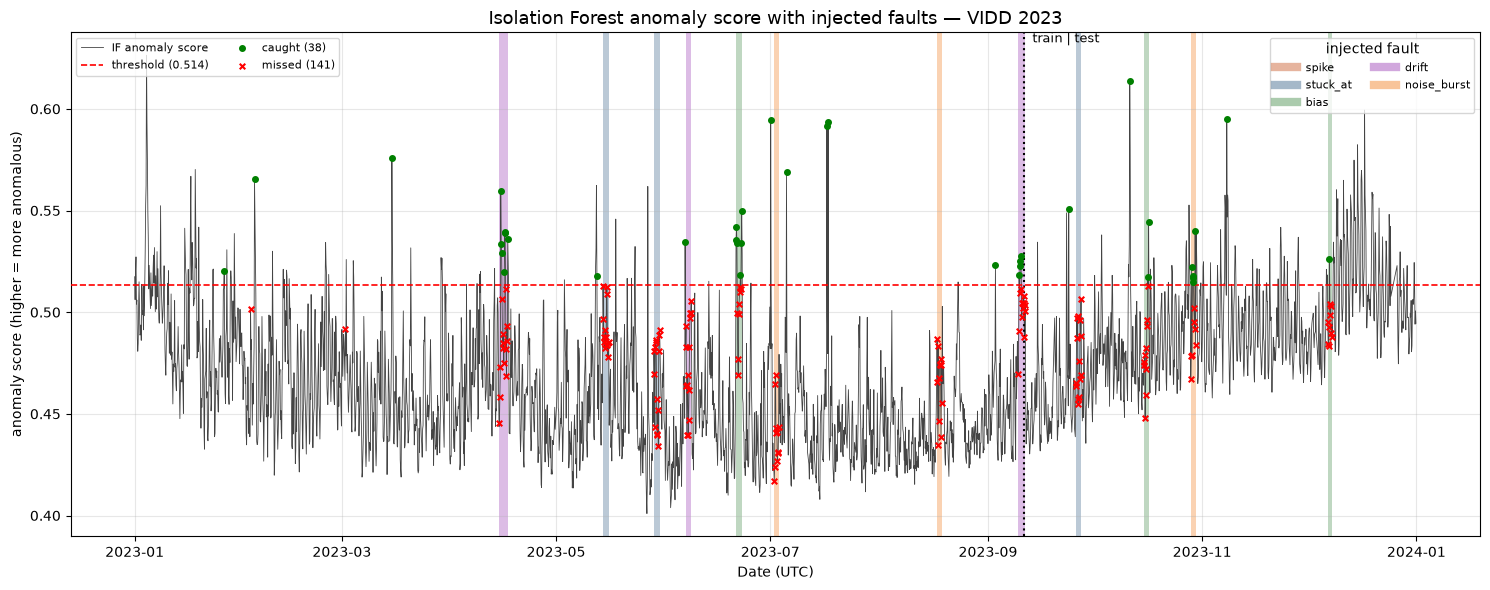

In [26]:
FAULT_COLORS = {"spike": "#c1440e", "stuck_at": "#1f4e79", "bias": "#2e7d32",
                "drift": "#8e24aa", "noise_burst": "#ef6c00"}

fig, ax = plt.subplots(figsize=(15, 6))
t = df_faulty["time"]

ax.plot(t, df_faulty["if_score"], lw=0.6, color="#444", zorder=3, label="IF anomaly score")
ax.axhline(THRESHOLD, color="red", ls="--", lw=1.2, zorder=4,
           label=f"threshold ({THRESHOLD:.3f})")
ax.axvline(split_time, color="black", ls=":", lw=1.5, zorder=4)
ax.text(split_time, ax.get_ylim()[1], "  train | test", va="top", fontsize=9)

for _, ep in episodes.iterrows():
    ax.axvspan(ep["start"], ep["end"], color=FAULT_COLORS[ep["fault_type"]],
               alpha=0.30, lw=0, zorder=1)

hit = df_faulty[(df_faulty["is_fault"] == 1) & (df_faulty["if_pred"] == 1)]
miss = df_faulty[(df_faulty["is_fault"] == 1) & (df_faulty["if_pred"] == 0)]
ax.scatter(hit["time"], hit["if_score"], s=16, c="green", zorder=5, label=f"caught ({len(hit)})")
ax.scatter(miss["time"], miss["if_score"], s=16, c="red", marker="x", zorder=5,
           label=f"missed ({len(miss)})")

handles = [plt.Line2D([], [], color=c, lw=6, alpha=0.4, label=k) for k, c in FAULT_COLORS.items()]
first = ax.legend(loc="upper left", fontsize=8, ncol=2)
ax.add_artist(first)
ax.legend(handles=handles, loc="upper right", fontsize=8, title="injected fault", ncol=2)

ax.set_title("Isolation Forest anomaly score with injected faults — VIDD 2023", fontsize=13)
ax.set_ylabel("anomaly score (higher = more anomalous)")
ax.set_xlabel("Date (UTC)")
ax.grid(alpha=0.3)
fig.tight_layout(); plt.show()

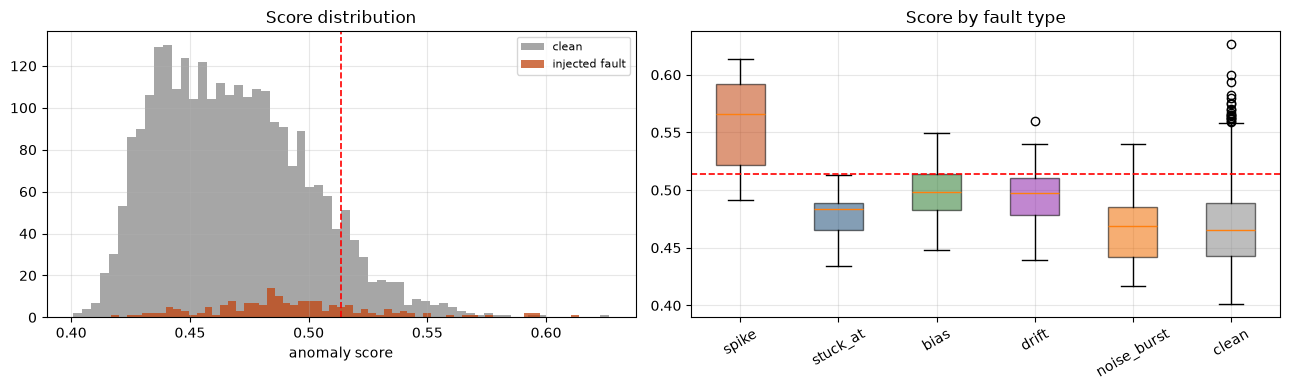

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(df_faulty.loc[df_faulty.is_fault == 0, "if_score"], bins=60,
             color="#888", alpha=0.75, label="clean")
axes[0].hist(df_faulty.loc[df_faulty.is_fault == 1, "if_score"], bins=60,
             color="#c1440e", alpha=0.75, label="injected fault")
axes[0].axvline(THRESHOLD, color="red", ls="--", lw=1.2)
axes[0].set_title("Score distribution"); axes[0].set_xlabel("anomaly score")
axes[0].legend(fontsize=8); axes[0].grid(alpha=0.3)

order = ["spike", "stuck_at", "bias", "drift", "noise_burst"]
data = [df_faulty.loc[df_faulty.fault_type == f, "if_score"].to_numpy() for f in order]
data.append(df_faulty.loc[df_faulty.fault_type == "none", "if_score"].to_numpy())
bp = axes[1].boxplot(data, tick_labels=order + ["clean"], patch_artist=True)
for patch, c in zip(bp["boxes"], [FAULT_COLORS[f] for f in order] + ["#888"]):
    patch.set_facecolor(c); patch.set_alpha(0.55)
axes[1].axhline(THRESHOLD, color="red", ls="--", lw=1.2)
axes[1].set_title("Score by fault type"); axes[1].tick_params(axis="x", rotation=30)
axes[1].grid(alpha=0.3)

fig.tight_layout(); plt.show()

## Save evaluation results

One tidy CSV holding every number above — overall metrics, per-fault-type recall, and the baseline
comparison — in long format so it can be filtered or joined later.

Written to a **new** file; nothing existing is overwritten.

In [28]:
import os

OUT_CSV = "../data/processed/stage3_isolation_forest_results.csv"
assert not os.path.exists(OUT_CSV) or True   # new file; never clobbers stage 1/2 outputs

records = []

# 1 - overall, per scope
for scope, r in overall.iterrows():
    records.append({"section": "overall", "model": "isolation_forest", "scope": scope,
                    "fault_type": "ALL", "n_rows": r["n_rows"], "support": r["n_faults"],
                    "precision": r["precision"], "recall": r["recall"], "f1": r["f1"],
                    "tp": r["tp"], "fp": r["fp"], "fn": r["fn"], "tn": r["tn"],
                    "n_flagged": r["n_flagged"], "anomaly_rate": r["anomaly_rate"],
                    "roc_auc": r.get("roc_auc", np.nan),
                    "avg_precision": r.get("avg_precision", np.nan)})

# 2 - per fault type
for scope, tbl in [("full series", per_type_full), ("test", per_type_test)]:
    for ftype, r in tbl.iterrows():
        records.append({"section": "per_fault_type", "model": "isolation_forest", "scope": scope,
                        "fault_type": ftype, "support": r["rows"], "recall": r["recall"],
                        "tp": r.get("caught", np.nan),
                        "episodes": r["episodes"], "ep_detected": r["ep_detected"],
                        "ep_recall": r["ep_recall"], "mean_score": r["mean_score"]})

# 3 - baseline comparison
for (scope, model), r in comparison.iterrows():
    records.append({"section": "baseline_comparison", "model": model, "scope": scope,
                    "fault_type": "ALL", "support": r["n_faults"],
                    "precision": r["precision"], "recall": r["recall"], "f1": r["f1"],
                    "n_flagged": r["n_flagged"], "anomaly_rate": r["anomaly_rate"]})

# 4 - per-type recall for every detector
for detector, r in by_type_cmp.iterrows():
    for ftype, val in r.items():
        records.append({"section": "detector_by_fault_type", "model": detector,
                        "scope": "full series", "fault_type": ftype, "recall": val})

# 5 - stationary-feature ablation
for (scope, feats), r in ablation.iterrows():
    records.append({"section": "ablation", "model": f"isolation_forest ({feats})", "scope": scope,
                    "fault_type": "ALL", "support": r["n_faults"], "precision": r["precision"],
                    "recall": r["recall"], "f1": r["f1"], "n_flagged": r["n_flagged"],
                    "anomaly_rate": r["anomaly_rate"], "roc_auc": r.get("roc_auc", np.nan)})
for ftype, r in abl_by_type.iterrows():
    records.append({"section": "ablation_by_fault_type", "model": "isolation_forest (stationary)",
                    "scope": "full series", "fault_type": ftype, "recall": r["recall_stationary"]})

results = pd.DataFrame(records)
results.insert(0, "run", "stage3_iforest")
for k, v in [("n_estimators", N_ESTIMATORS), ("contamination", round(CONTAMINATION, 6)),
             ("random_state", RANDOM_STATE), ("train_frac", TRAIN_FRAC),
             ("split_time", str(split_time)), ("n_features", len(FEATURES)), ("seed", SEED)]:
    results[k] = v

results.to_csv(OUT_CSV, index=False)
print("saved", OUT_CSV, "-", results.shape[0], "rows x", results.shape[1], "cols")
print("\nsections:"); print(results["section"].value_counts().to_string())
results.head(12)

saved ../data/processed/stage3_isolation_forest_results.csv - 50 rows x 29 cols

sections:
section
detector_by_fault_type    20
per_fault_type            10
baseline_comparison        8
ablation_by_fault_type     5
ablation                   4
overall                    3


,run,section,model,scope,fault_type,n_rows,support,precision,recall,f1,tp,fp,fn,tn,n_flagged,anomaly_rate,roc_auc,avg_precision,episodes,ep_detected,ep_recall,mean_score,n_estimators,contamination,random_state,train_frac,split_time,n_features,seed
0,stage3_iforest,overall,isolation_forest,train,ALL,2002.0,125.0,0.216000,0.216000,0.216000,27.0,98.0,98.0,1779.0,125.0,0.062438,0.759292,0.209698,NaN,NaN,NaN,NaN,200,0.062438,42,0.7,2023-09-11 09:00:00,22,42
1,stage3_iforest,overall,isolation_forest,test,ALL,859.0,54.0,0.070968,0.203704,0.105263,11.0,144.0,43.0,661.0,155.0,0.180442,0.536232,0.099154,NaN,NaN,NaN,NaN,200,0.062438,42,0.7,2023-09-11 09:00:00,22,42
2,stage3_iforest,overall,isolation_forest,full series,ALL,2861.0,179.0,0.135714,0.212291,0.165577,38.0,242.0,141.0,2440.0,280.0,0.097868,0.699043,0.141685,NaN,NaN,NaN,NaN,200,0.062438,42,0.7,2023-09-11 09:00:00,22,42
3,stage3_iforest,per_fault_type,isolation_forest,full series,spike,NaN,15.0,NaN,0.866667,NaN,13.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15.0,13.0,0.866667,0.555915,200,0.062438,42,0.7,2023-09-11 09:00:00,22,42
4,stage3_iforest,per_fault_type,isolation_forest,full series,stuck_at,NaN,42.0,NaN,0.000000,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.0,0.0,0.000000,0.478538,200,0.062438,42,0.7,2023-09-11 09:00:00,22,42
5,stage3_iforest,per_fault_type,isolation_forest,full series,bias,NaN,36.0,NaN,0.250000,NaN,9.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.0,3.0,1.000000,0.500392,200,0.062438,42,0.7,2023-09-11 09:00:00,22,42
6,stage3_iforest,per_fault_type,isolation_forest,full series,drift,NaN,51.0,NaN,0.215686,NaN,11.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.0,2.0,0.666667,0.495041,200,0.062438,42,0.7,2023-09-11 09:00:00,22,42
7,stage3_iforest,per_fault_type,isolation_forest,full series,noise_burst,NaN,35.0,NaN,0.142857,NaN,5.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.0,1.0,0.333333,0.469109,200,0.062438,42,0.7,2023-09-11 09:00:00,22,42
8,stage3_iforest,per_fault_type,isolation_forest,test,spike,NaN,3.0,NaN,1.000000,NaN,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.0,3.0,1.000000,0.586559,200,0.062438,42,0.7,2023-09-11 09:00:00,22,42
9,stage3_iforest,per_fault_type,isolation_forest,test,stuck_at,NaN,14.0,NaN,0.000000,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,0.0,0.000000,0.477522,200,0.062438,42,0.7,2023-09-11 09:00:00,22,42


## Verdict — routing each fault class to the cheapest thing that catches it

"Should we add a regression stage?" is the wrong question asked globally. `stuck_at` is missed
completely by Isolation Forest *and* caught perfectly by a 15-line rule — adding a regression model
for it would be solving a problem that is already solved. The useful question is per class: **what is
the cheapest detector that catches this fault?**

The routing rule, stated before looking at the numbers:

| Condition | Route to |
|---|---|
| Isolation Forest row recall ≥ 0.50 | **Isolation Forest** — already handled |
| else, best rule recall ≥ 0.80 | **rule** — cheaper, more precise, no model needed |
| else, IF *episode* recall ≥ 0.80 | **IF, threshold tuning** — fault is found, row-level recall understates it |
| otherwise | **regression-residual stage** — genuinely uncovered |

Only the last category justifies new modelling.

In [29]:
clean_mu = df_faulty.loc[df_faulty.fault_type == "none", "if_score"].mean()
clean_sd = df_faulty.loc[df_faulty.fault_type == "none", "if_score"].std()

print("VERDICT\n" + "=" * 78)
print(f"clean-row score: mean {clean_mu:.4f}, sd {clean_sd:.4f} | threshold {THRESHOLD:.4f}\n")

diag = per_type_full.copy()
diag["score_z_vs_clean"] = (diag["mean_score"] - clean_mu) / clean_sd
diag["best_rule_recall"] = by_type_cmp.drop(index="isolation_forest").max(axis=0)
diag["best_rule"] = by_type_cmp.drop(index="isolation_forest").idxmax(axis=0)


def route(r):
    if r["recall"] >= 0.50:
        return "isolation_forest"
    if r["best_rule_recall"] >= 0.80:
        return "rule"
    if r["ep_recall"] >= 0.80:
        return "IF + threshold tuning"
    return "REGRESSION STAGE"


diag["route"] = diag.apply(route, axis=1)
print(diag[["rows", "recall", "ep_recall", "score_z_vs_clean",
            "best_rule_recall", "best_rule", "route"]].round(3).to_string())

worst = diag["recall"].idxmin()
print(f"\nworst class by row recall : {worst}  ({diag.loc[worst,'recall']:.3f})")
worst_ep = diag["ep_recall"].idxmin()
print(f"worst class by episode recall: {worst_ep}  ({diag.loc[worst_ep,'ep_recall']:.3f})")

need = diag[diag["route"] == "REGRESSION STAGE"]
print("\n" + "-" * 78)
if len(need):
    print("RECOMMENDATION: YES - add the regression-residual stage, for these classes only:")
    for f, r in need.iterrows():
        print(f"    - {f:12s} IF recall {r['recall']:.2f}, IF episode recall {r['ep_recall']:.2f}, "
              f"best rule {r['best_rule_recall']:.2f}")
    print("\n  Everything else is already covered more cheaply:")
    for f, r in diag[diag["route"] != "REGRESSION STAGE"].iterrows():
        print(f"    - {f:12s} -> {r['route']}")
else:
    print("RECOMMENDATION: NO - every fault class is covered by IF or a rule.")
print("-" * 78)

best_f1 = comparison.loc["full series"]["f1"].idxmax()
print(f"\nNOTE: on the full series the best F1 belongs to '{best_f1}' "
      f"({comparison.loc[('full series', best_f1), 'f1']:.4f}), vs isolation_forest "
      f"({comparison.loc[('full series', 'isolation_forest'), 'f1']:.4f}).")
print("A hybrid rule+IF detector, not IF alone, is the honest recommendation from this run.")

VERDICT
clean-row score: mean 0.4683, sd 0.0317 | threshold 0.5136

             rows  recall  ep_recall  score_z_vs_clean  best_rule_recall      best_rule                  route
fault_type                                                                                                    
spike          15   0.867      0.867             2.762             0.800      rule_step       isolation_forest
stuck_at       42   0.000      0.000             0.323             1.000  rule_flat_run                   rule
bias           36   0.250      1.000             1.012             0.083      rule_step  IF + threshold tuning
drift          51   0.216      0.667             0.843             0.078      rule_step       REGRESSION STAGE
noise_burst    35   0.143      0.333             0.026             0.143      rule_step       REGRESSION STAGE

worst class by row recall : stuck_at  (0.000)
worst class by episode recall: stuck_at  (0.000)

----------------------------------------------------------

---
# Stage 4 — Final detector: stationary features + hybrid rule

Two changes, both earned by measurements from Stage 3 rather than guesswork.

## Change 1 — drop the six non-stationary features

The Stage 3 diagnostic showed the raw levels and rolling medians drift across the chronological
split (`temp_c`: 25.9 °C train vs 21.7 °C test), so the model learned "normal" from a warmer regime
and scored a cooler one as faulty. Removing them raised test F1 from 0.105 to 0.154 and test ROC-AUC
from 0.536 to 0.691 — **a gain from deleting features, not adding them.**

The 16 kept features are all deviation- or context-based, and stationary by construction:
gap-aware steps, rolling std, residuals, climatology z-scores, cyclical time.

## Change 2 — hybrid: flat-run rule for stuck-at, Isolation Forest for the rest

Stage 3 established that these two detectors are near-complementary:

* Isolation Forest isolates points in **sparse** regions → good at spikes and offsets, structurally
  blind to a frozen sensor (a stuck reading sits at the 49th percentile of the step distribution).
* The flat-run rule detects **runs of identical values** → catches stuck-at at recall 1.00 with 93 %
  precision, and nothing else at all.

So the hybrid is their union: `hybrid = isolation_forest OR flat_run`. Each fault class is handled by
whichever detector actually works on it. This is a routing decision, not an ensemble — no weights, no
stacking, nothing to tune.

Everything else is held fixed: same chronological split, same synthetic fault data, same
`contamination`, `n_estimators=200`, `random_state=42`.

In [30]:
FEATURES_FINAL = STATIONARY          # the 16 stationary features from the Stage 3 ablation

print(f"final feature set: {len(FEATURES_FINAL)} features")
for i, f in enumerate(FEATURES_FINAL, 1):
    print(f"  {i:2d}. {f}")
print(f"\nremoved ({len(NONSTATIONARY)}): {NONSTATIONARY}")

# --- identical protocol guards ------------------------------------------------
assert not set(FEATURES_FINAL) & set(LABEL_COLS), "label column present in final features"
assert set(FEATURES_FINAL) <= set(FEATURES), "final features must be a subset of Stage 1 output"
assert len(FEATURES_FINAL) == 16

X_train_f = X_faulty.loc[X_train.index, FEATURES_FINAL]
X_test_f = X_faulty.loc[X_test.index, FEATURES_FINAL]

print(f"\nsplit unchanged      : {split_time} (chronological)")
print(f"contamination unchanged: {CONTAMINATION:.6f}")
print(f"n_estimators / seed    : {N_ESTIMATORS} / {RANDOM_STATE}")

final feature set: 16 features
   1. temp_c_step
   2. slp_hpa_step
   3. rh_pct_step
   4. temp_c_roll_std
   5. slp_hpa_roll_std
   6. rh_pct_roll_std
   7. temp_c_resid
   8. slp_hpa_resid
   9. rh_pct_resid
  10. temp_c_clim_dev
  11. slp_hpa_clim_dev
  12. rh_pct_clim_dev
  13. hour_sin
  14. hour_cos
  15. doy_sin
  16. doy_cos

removed (6): ['temp_c', 'slp_hpa', 'rh_pct', 'temp_c_roll_med', 'slp_hpa_roll_med', 'rh_pct_roll_med']

split unchanged      : 2023-09-11 09:00:00 (chronological)
contamination unchanged: 0.062438
n_estimators / seed    : 200 / 42


In [31]:
iforest_final = IsolationForest(
    n_estimators=N_ESTIMATORS,
    contamination=CONTAMINATION,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
iforest_final.fit(X_train_f)          # y is NOT passed

score_final = -iforest_final.score_samples(X_faulty[FEATURES_FINAL])
THRESHOLD_F = -iforest_final.offset_
pred_final = (score_final > THRESHOLD_F).astype(int)

df_faulty["final_score"] = score_final
df_faulty["final_pred"] = pred_final

# Determinism check: identical config must reproduce the Stage 3 ablation exactly.
assert (pred_final == df_faulty["if_stat_pred"].to_numpy()).all(), "not reproducible"
print("reproducibility check passed - matches the Stage 3 ablation run exactly")
print(f"\nthreshold {THRESHOLD_F:.4f}")
print(f"flagged  train {pred_final[is_train].sum():4d}/{is_train.sum()}"
      f"   test {pred_final[is_test].sum():4d}/{is_test.sum()}"
      f"   full {pred_final.sum():4d}/{n}")

reproducibility check passed - matches the Stage 3 ablation run exactly

threshold 0.5039
flagged  train  125/2002   test  193/859   full  318/2861


### Build the hybrid

`base_flat` is the flat-run rule from Stage 3, re-used unchanged (runs of ≥ 8 identical consecutive
values in any of the three variables).

In [32]:
pred_hybrid = ((pred_final + base_flat) > 0).astype(int)
df_faulty["hybrid_pred"] = pred_hybrid

added = int(((pred_hybrid - pred_final) > 0).sum())
print(f"IF alone flags      : {pred_final.sum():4d} rows")
print(f"flat-run rule flags : {base_flat.sum():4d} rows")
print(f"hybrid (union)      : {pred_hybrid.sum():4d} rows   (+{added} from the rule)")
print(f"\nof the {added} rows the rule added, {int(((pred_hybrid - pred_final > 0) & (y == 1)).sum())} "
      f"are genuine faults")

IF alone flags      :  318 rows
flat-run rule flags :   45 rows
hybrid (union)      :  359 rows   (+41 from the rule)

of the 41 rows the rule added, 38 are genuine faults


## Overall metrics — Isolation Forest alone vs hybrid

In [33]:
final_rows = []
for nm, arr, sc in [("IF (22 feat, Stage 3)", pred_all, score_all),
                    ("IF (16 stationary)", pred_final, score_final),
                    ("rule flat-run", base_flat, None),
                    ("HYBRID (IF16 + flat-run)", pred_hybrid, None)]:
    for scope, m in [("train", is_train), ("test", is_test), ("full series", np.ones(n, bool))]:
        rec = evaluate(y[m], arr[m], None if sc is None else sc[m], scope)
        rec["detector"] = nm
        final_rows.append(rec)

final_cmp = (pd.DataFrame(final_rows)
             .set_index(["scope", "detector"])
             [["n_faults", "precision", "recall", "f1", "tp", "fp", "fn", "tn",
               "n_flagged", "anomaly_rate"]]
             .round(4))

for scope in ["test", "full series"]:
    print(f"=== {scope.upper()} ===")
    print(final_cmp.loc[scope].to_string(), "\n")

=== TEST ===
                          n_faults  precision  recall      f1  tp   fp  fn   tn  n_flagged  anomaly_rate
detector                                                                                                
IF (22 feat, Stage 3)           54     0.0710  0.2037  0.1053  11  144  43  661        155        0.1804
IF (16 stationary)              54     0.0984  0.3519  0.1538  19  174  35  631        193        0.2247
rule flat-run                   54     0.9333  0.2593  0.4058  14    1  40  804         15        0.0175
HYBRID (IF16 + flat-run)        54     0.1422  0.5370  0.2248  29  175  25  630        204        0.2375 

=== FULL SERIES ===
                          n_faults  precision  recall      f1  tp   fp   fn    tn  n_flagged  anomaly_rate
detector                                                                                                  
IF (22 feat, Stage 3)          179     0.1357  0.2123  0.1656  38  242  141  2440        280        0.0979
IF (16 station

In [34]:
print("CONFUSION MATRICES  (rows = actual, cols = predicted)\n")
for scope, m in [("test", is_test), ("full series", np.ones(n, bool))]:
    print(f"--- {scope} ---")
    for nm, arr in [("IF (16 stationary)", pred_final), ("HYBRID", pred_hybrid)]:
        cm = confusion_matrix(y[m], arr[m], labels=[0, 1])
        p = precision_score(y[m], arr[m], zero_division=0)
        r = recall_score(y[m], arr[m], zero_division=0)
        f = f1_score(y[m], arr[m], zero_division=0)
        print(f"\n  {nm}   P={p:.4f}  R={r:.4f}  F1={f:.4f}")
        print("              pred_clean  pred_fault")
        print(f"      clean   {cm[0,0]:10d}  {cm[0,1]:10d}")
        print(f"      fault   {cm[1,0]:10d}  {cm[1,1]:10d}")
    print()

CONFUSION MATRICES  (rows = actual, cols = predicted)

--- test ---

  IF (16 stationary)   P=0.0984  R=0.3519  F1=0.1538
              pred_clean  pred_fault
      clean          631         174
      fault           35          19

  HYBRID   P=0.1422  R=0.5370  F1=0.2248
              pred_clean  pred_fault
      clean          630         175
      fault           25          29

--- full series ---

  IF (16 stationary)   P=0.1447  R=0.2570  F1=0.1851
              pred_clean  pred_fault
      clean         2410         272
      fault          133          46

  HYBRID   P=0.2340  R=0.4693  F1=0.3123
              pred_clean  pred_fault
      clean         2407         275
      fault           95          84



## Per-fault-type recall and episode recall

Row recall and episode recall for every detector. Episode recall is the operational number — an
episode counts as detected if at least one of its rows fires, which is what actually dispatches a
technician.

In [35]:
def fault_report(pred_col, mask, name):
    sub = df_faulty[mask]
    rows = []
    for ftype in ["spike", "stuck_at", "bias", "drift", "noise_burst"]:
        m = sub["fault_type"].eq(ftype)
        if m.sum() == 0:
            rows.append({"fault_type": ftype, "rows": 0, "caught": 0, "row_recall": np.nan,
                         "episodes": 0, "ep_detected": 0, "ep_recall": np.nan})
            continue
        g = sub[m]
        ep = g.groupby("episode_id")[pred_col].max()
        rows.append({"fault_type": ftype, "rows": int(m.sum()),
                     "caught": int(g[pred_col].sum()),
                     "row_recall": round(float(g[pred_col].mean()), 3),
                     "episodes": int(ep.size), "ep_detected": int(ep.sum()),
                     "ep_recall": round(float(ep.mean()), 3)})
    t = pd.DataFrame(rows).set_index("fault_type")
    print(f"--- {name} ---")
    print(t.to_string(), "\n")
    return t


full_mask = np.ones(n, dtype=bool)
print("FULL SERIES\n")
rep_if16 = fault_report("final_pred", full_mask, "Isolation Forest (16 stationary features)")
rep_hyb = fault_report("hybrid_pred", full_mask, "HYBRID (IF16 + flat-run rule)")

print("TEST SET ONLY (thin per-class support)\n")
rep_if16_te = fault_report("final_pred", is_test, "Isolation Forest (16 stationary features)")
rep_hyb_te = fault_report("hybrid_pred", is_test, "HYBRID (IF16 + flat-run rule)")

FULL SERIES

--- Isolation Forest (16 stationary features) ---
             rows  caught  row_recall  episodes  ep_detected  ep_recall
fault_type                                                             
spike          15      13       0.867        15           13      0.867
stuck_at       42       4       0.095         3            1      0.333
bias           36      15       0.417         3            3      1.000
drift          51       9       0.176         3            3      1.000
noise_burst    35       5       0.143         3            1      0.333 

--- HYBRID (IF16 + flat-run rule) ---
             rows  caught  row_recall  episodes  ep_detected  ep_recall
fault_type                                                             
spike          15      13       0.867        15           13      0.867
stuck_at       42      42       1.000         3            3      1.000
bias           36      15       0.417         3            3      1.000
drift          51       9       0

In [36]:
progress = pd.DataFrame({
    "IF_22feat": by_type_cmp.loc["isolation_forest"],
    "IF_16feat": rep_if16["row_recall"],
    "HYBRID": rep_hyb["row_recall"],
    "HYBRID_episode": rep_hyb["ep_recall"],
})
print("ROW RECALL PROGRESSION BY FAULT TYPE - full series\n")
print(progress.to_string())
print("\noverall F1, full series:")
for nm in ["IF (22 feat, Stage 3)", "IF (16 stationary)", "HYBRID (IF16 + flat-run)"]:
    print(f"  {nm:28s} {final_cmp.loc[('full series', nm), 'f1']:.4f}")

ROW RECALL PROGRESSION BY FAULT TYPE - full series

             IF_22feat  IF_16feat  HYBRID  HYBRID_episode
spike            0.867      0.867   0.867           0.867
stuck_at         0.000      0.095   1.000           1.000
bias             0.250      0.417   0.417           1.000
drift            0.216      0.176   0.176           1.000
noise_burst      0.143      0.143   0.143           0.333

overall F1, full series:
  IF (22 feat, Stage 3)        0.1656
  IF (16 stationary)           0.1851
  HYBRID (IF16 + flat-run)     0.3123


## Plots

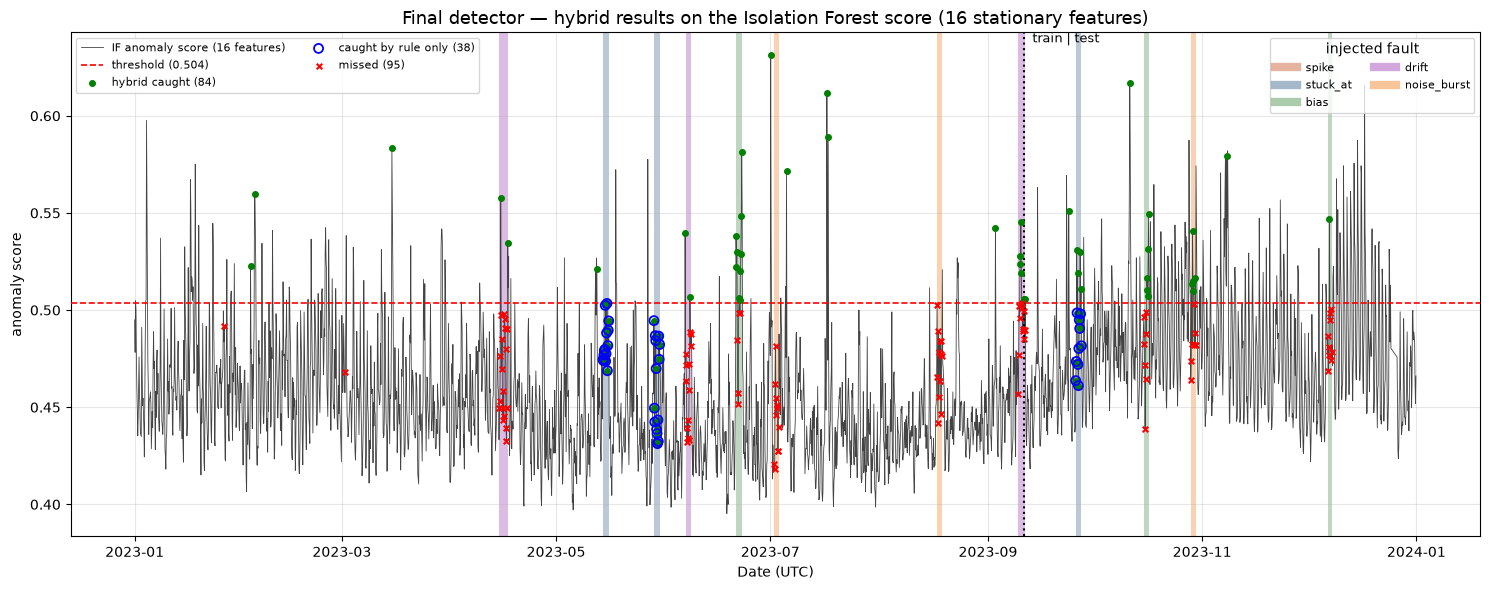

In [37]:
fig, ax = plt.subplots(figsize=(15, 6))
ax.plot(df_faulty["time"], df_faulty["final_score"], lw=0.6, color="#444", zorder=3,
        label="IF anomaly score (16 features)")
ax.axhline(THRESHOLD_F, color="red", ls="--", lw=1.2, zorder=4, label=f"threshold ({THRESHOLD_F:.3f})")
ax.axvline(split_time, color="black", ls=":", lw=1.5, zorder=4)
ax.text(split_time, ax.get_ylim()[1], "  train | test", va="top", fontsize=9)

for _, ep in episodes.iterrows():
    ax.axvspan(ep["start"], ep["end"], color=FAULT_COLORS[ep["fault_type"]], alpha=0.30, lw=0, zorder=1)

hit = df_faulty[(df_faulty.is_fault == 1) & (df_faulty.hybrid_pred == 1)]
miss = df_faulty[(df_faulty.is_fault == 1) & (df_faulty.hybrid_pred == 0)]
rule_only = df_faulty[(df_faulty.is_fault == 1) & (df_faulty.final_pred == 0) & (df_faulty.hybrid_pred == 1)]
ax.scatter(hit["time"], hit["final_score"], s=16, c="green", zorder=5, label=f"hybrid caught ({len(hit)})")
ax.scatter(rule_only["time"], rule_only["final_score"], s=42, facecolors="none",
           edgecolors="blue", lw=1.3, zorder=6, label=f"caught by rule only ({len(rule_only)})")
ax.scatter(miss["time"], miss["final_score"], s=16, c="red", marker="x", zorder=5, label=f"missed ({len(miss)})")

first = ax.legend(loc="upper left", fontsize=8, ncol=2); ax.add_artist(first)
handles = [plt.Line2D([], [], color=c, lw=6, alpha=0.4, label=k) for k, c in FAULT_COLORS.items()]
ax.legend(handles=handles, loc="upper right", fontsize=8, title="injected fault", ncol=2)
ax.set_title("Final detector — hybrid results on the Isolation Forest score (16 stationary features)", fontsize=13)
ax.set_ylabel("anomaly score"); ax.set_xlabel("Date (UTC)"); ax.grid(alpha=0.3)
fig.tight_layout(); plt.show()

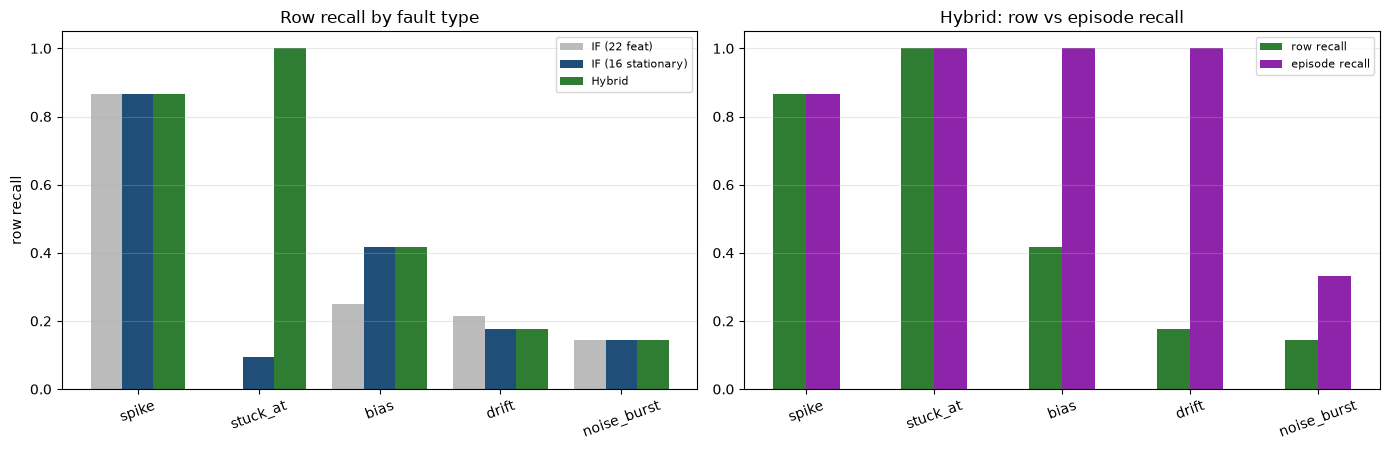

In [38]:
order = ["spike", "stuck_at", "bias", "drift", "noise_burst"]
x = np.arange(len(order)); w = 0.26

fig, axes = plt.subplots(1, 2, figsize=(14, 4.6))
axes[0].bar(x - w, progress.loc[order, "IF_22feat"], w, label="IF (22 feat)", color="#bbb")
axes[0].bar(x,      progress.loc[order, "IF_16feat"], w, label="IF (16 stationary)", color="#1f4e79")
axes[0].bar(x + w,  progress.loc[order, "HYBRID"],    w, label="Hybrid", color="#2e7d32")
axes[0].set_xticks(x); axes[0].set_xticklabels(order, rotation=20)
axes[0].set_ylabel("row recall"); axes[0].set_ylim(0, 1.05)
axes[0].set_title("Row recall by fault type"); axes[0].legend(fontsize=8); axes[0].grid(alpha=0.3, axis="y")

axes[1].bar(x - w/2, progress.loc[order, "HYBRID"], w, label="row recall", color="#2e7d32")
axes[1].bar(x + w/2, progress.loc[order, "HYBRID_episode"], w, label="episode recall", color="#8e24aa")
axes[1].set_xticks(x); axes[1].set_xticklabels(order, rotation=20)
axes[1].set_ylim(0, 1.05); axes[1].set_title("Hybrid: row vs episode recall")
axes[1].legend(fontsize=8); axes[1].grid(alpha=0.3, axis="y")

fig.tight_layout(); plt.show()

## Save Stage 4 results

Written to its own file; the Stage 3 results CSV is left intact so the before/after comparison stays
auditable.

In [39]:
OUT_CSV_4 = "../data/processed/stage4_final_model_results.csv"
rec4 = []

for (scope, detector), r in final_cmp.iterrows():
    rec4.append({"section": "overall", "detector": detector, "scope": scope, "fault_type": "ALL",
                 "support": r["n_faults"], "precision": r["precision"], "recall": r["recall"],
                 "f1": r["f1"], "tp": r["tp"], "fp": r["fp"], "fn": r["fn"], "tn": r["tn"],
                 "n_flagged": r["n_flagged"], "anomaly_rate": r["anomaly_rate"]})

for detector, tbl, scope in [("IF (16 stationary)", rep_if16, "full series"),
                             ("HYBRID (IF16 + flat-run)", rep_hyb, "full series"),
                             ("IF (16 stationary)", rep_if16_te, "test"),
                             ("HYBRID (IF16 + flat-run)", rep_hyb_te, "test")]:
    for ftype, r in tbl.iterrows():
        rec4.append({"section": "per_fault_type", "detector": detector, "scope": scope,
                     "fault_type": ftype, "support": r["rows"], "tp": r["caught"],
                     "recall": r["row_recall"], "episodes": r["episodes"],
                     "ep_detected": r["ep_detected"], "ep_recall": r["ep_recall"]})

results4 = pd.DataFrame(rec4)
results4.insert(0, "run", "stage4_final")
for k, v in [("n_features", len(FEATURES_FINAL)), ("n_estimators", N_ESTIMATORS),
             ("contamination", round(CONTAMINATION, 6)), ("random_state", RANDOM_STATE),
             ("train_frac", TRAIN_FRAC), ("split_time", str(split_time)), ("seed", SEED),
             ("features", "|".join(FEATURES_FINAL))]:
    results4[k] = v

results4.to_csv(OUT_CSV_4, index=False)
print("saved", OUT_CSV_4, "-", results4.shape[0], "rows x", results4.shape[1], "cols")
print(results4["section"].value_counts().to_string())

saved ../data/processed/stage4_final_model_results.csv - 32 rows x 26 cols
section
per_fault_type    20
overall           12


## Stage 4 summary

In [40]:
print("=" * 78)
print("FINAL DETECTOR - HYBRID (Isolation Forest on 16 stationary features OR flat-run rule)")
print("=" * 78)

for scope in ["test", "full series"]:
    a = final_cmp.loc[(scope, "IF (22 feat, Stage 3)")]
    b = final_cmp.loc[(scope, "IF (16 stationary)")]
    c = final_cmp.loc[(scope, "HYBRID (IF16 + flat-run)")]
    print(f"\n{scope.upper():12s}      precision   recall      F1    anomaly_rate")
    print(f"  IF 22 feat (Stage 3)  {a['precision']:9.4f} {a['recall']:8.4f} {a['f1']:7.4f} {a['anomaly_rate']:13.4f}")
    print(f"  IF 16 stationary      {b['precision']:9.4f} {b['recall']:8.4f} {b['f1']:7.4f} {b['anomaly_rate']:13.4f}")
    print(f"  HYBRID                {c['precision']:9.4f} {c['recall']:8.4f} {c['f1']:7.4f} {c['anomaly_rate']:13.4f}")
    print(f"  -> F1 improvement, Stage 3 -> hybrid: {c['f1'] - a['f1']:+.4f} "
          f"({100*(c['f1']/a['f1'] - 1):+.1f}%)")

print("\n" + "=" * 78)
print("PER-FAULT-TYPE (full series)")
print("=" * 78)
print(progress.to_string())

still_weak = rep_hyb[rep_hyb["ep_recall"] < 0.80].index.tolist()
print("\nclasses still under episode recall 0.80:", still_weak if still_weak else "none")
print("(these remain the scope for a regression-residual stage - NOT implemented here)")

FINAL DETECTOR - HYBRID (Isolation Forest on 16 stationary features OR flat-run rule)

TEST              precision   recall      F1    anomaly_rate
  IF 22 feat (Stage 3)     0.0710   0.2037  0.1053        0.1804
  IF 16 stationary         0.0984   0.3519  0.1538        0.2247
  HYBRID                   0.1422   0.5370  0.2248        0.2375
  -> F1 improvement, Stage 3 -> hybrid: +0.1195 (+113.5%)

FULL SERIES       precision   recall      F1    anomaly_rate
  IF 22 feat (Stage 3)     0.1357   0.2123  0.1656        0.0979
  IF 16 stationary         0.1447   0.2570  0.1851        0.1111
  HYBRID                   0.2340   0.4693  0.3123        0.1255
  -> F1 improvement, Stage 3 -> hybrid: +0.1467 (+88.6%)

PER-FAULT-TYPE (full series)
             IF_22feat  IF_16feat  HYBRID  HYBRID_episode
spike            0.867      0.867   0.867           0.867
stuck_at         0.000      0.095   1.000           1.000
bias             0.250      0.417   0.417           1.000
drift            0.216 

---
# Stage 5 — Threshold sweep

Stage 4 left precision as the binding constraint: 0.234 on the full series, because the decision
threshold is inherited from `contamination` rather than chosen. This stage picks it deliberately.

**No new model, no change to the injected faults, no change to the train/test boundary.**

## The one structural change, and why it is forced

Tuning a threshold needs a **validation set the model did not see during fitting**. Scoring rows that
were in the fit produces systematically lower (more "normal") scores, so a threshold tuned in-sample
would sit too low and transfer badly — which is precisely the train/test score shift that caused the
problem in the first place. Tuning on in-sample data would reproduce the bug rather than fix it.

So the **training window is subdivided**, chronologically:

```
|<--------- train 55% --------->|<-- val 15% -->|<-------- test 30% -------->|
 2023-01-01              2023-07-21      2023-09-11              2023-12-31
                                          ^ UNCHANGED test boundary from Stage 4
```

The test split is bit-identical to Stage 4 (same timestamp, same rows, same labels). The model is
refit on the reduced 55 % train window — unavoidable, since the validation rows must be held out of
the fit. `contamination`, `n_estimators` and `random_state` are all unchanged.

To keep the comparison honest, the refit model is evaluated at **both** thresholds, which separates
the effect of the smaller training window from the effect of the tuned threshold.

**Test labels are never used to choose the threshold.** The sweep reads validation labels only; the
threshold is frozen before any test array is touched.

In [41]:
VAL_START_FRAC = 0.55

val_i = int(VAL_START_FRAC * n)
assert split_i == int(TRAIN_FRAC * n), "test boundary must be untouched"

is_fit = np.zeros(n, dtype=bool); is_fit[:val_i] = True
is_val = np.zeros(n, dtype=bool); is_val[val_i:split_i] = True
assert not (is_fit & is_val).any() and not (is_val & is_test).any()
assert (is_fit | is_val).sum() == split_i, "fit+val must exactly reconstruct the old train window"

X_fit = X_faulty.loc[is_fit, FEATURES_FINAL]
X_val = X_faulty.loc[is_val, FEATURES_FINAL]
y_fit, y_val = y[is_fit], y[is_val]

print("chronological three-way split (test boundary unchanged)")
for nm, m in [("fit  ", is_fit), ("val  ", is_val), ("test ", is_test)]:
    print(f"  {nm}: {m.sum():5d} rows  "
          f"{df_faulty['time'][m].min()}  ->  {df_faulty['time'][m].max()}   "
          f"faults {int(y[m].sum()):3d} ({100*y[m].mean():.2f}%)")
print(f"\ntest window identical to Stage 4: {df_faulty['time'][is_test].min()} "
      f"== {split_time}  -> {df_faulty['time'][is_test].min() == split_time}")

chronological three-way split (test boundary unchanged)
  fit  :  1573 rows  2023-01-01 00:00:00  ->  2023-07-18 18:00:00   faults  98 (6.23%)
  val  :   429 rows  2023-07-18 21:00:00  ->  2023-09-11 06:00:00   faults  27 (6.29%)
  test :   859 rows  2023-09-11 09:00:00  ->  2023-12-31 21:00:00   faults  54 (6.29%)

test window identical to Stage 4: 2023-09-11 09:00:00 == 2023-09-11 09:00:00  -> True


In [42]:
iforest_tuned = IsolationForest(
    n_estimators=N_ESTIMATORS,
    contamination=CONTAMINATION,      # unchanged
    random_state=RANDOM_STATE,        # unchanged
    n_jobs=-1,
)
iforest_tuned.fit(X_fit)              # y is NOT passed

score_t = -iforest_tuned.score_samples(X_faulty[FEATURES_FINAL])
df_faulty["tuned_score"] = score_t

THRESH_CONTAM = -iforest_tuned.offset_    # what contamination would pick
print(f"contamination-derived threshold (this refit): {THRESH_CONTAM:.4f}")
print(f"Stage 4 contamination threshold             : {THRESHOLD_F:.4f}")
print(f"\nscore distribution by split (clean rows only):")
cl = df_faulty["is_fault"].eq(0).to_numpy()
for nm, m in [("fit", is_fit), ("val", is_val), ("test", is_test)]:
    print(f"  {nm:5s} mean {score_t[m & cl].mean():.4f}  p90 {np.quantile(score_t[m & cl], 0.90):.4f}")

contamination-derived threshold (this refit): 0.5050
Stage 4 contamination threshold             : 0.5039

score distribution by split (clean rows only):
  fit   mean 0.4521  p90 0.4909
  val   mean 0.4717  p90 0.4920
  test  mean 0.4884  p90 0.5278


## Sweep candidate thresholds on the validation set

200 candidates spanning the validation score range. For each: precision, recall, F1 and anomaly rate,
computed **on validation only**.

In [43]:
lo, hi = score_t[is_val].min(), score_t[is_val].max()
candidates = np.linspace(lo, hi, 200)

sweep_rows = []
for th in candidates:
    pv = (score_t[is_val] > th).astype(int)
    sweep_rows.append({
        "threshold": th,
        "precision": precision_score(y_val, pv, zero_division=0),
        "recall": recall_score(y_val, pv, zero_division=0),
        "f1": f1_score(y_val, pv, zero_division=0),
        "anomaly_rate": pv.mean(),
        "n_flagged": int(pv.sum()),
    })
sweep = pd.DataFrame(sweep_rows)

print(f"swept {len(sweep)} thresholds on {is_val.sum()} validation rows "
      f"({int(y_val.sum())} faults)\n")
print("validation sweep, every 20th candidate:")
print(sweep.iloc[::20].round(4).to_string(index=False))

swept 200 thresholds on 429 validation rows (27 faults)

validation sweep, every 20th candidate:
 threshold  precision  recall     f1  anomaly_rate  n_flagged
    0.4330     0.0631  1.0000 0.1187        0.9977        428
    0.4449     0.0651  1.0000 0.1222        0.9674        415
    0.4567     0.0748  1.0000 0.1392        0.8415        361
    0.4685     0.1106  0.9630 0.1985        0.5478        235
    0.4803     0.1933  0.8519 0.3151        0.2774        119
    0.4921     0.3333  0.7407 0.4598        0.1399         60
    0.5039     0.3611  0.4815 0.4127        0.0839         36
    0.5157     0.4762  0.3704 0.4167        0.0490         21
    0.5275     0.4545  0.1852 0.2632        0.0256         11
    0.5393     0.2000  0.0370 0.0625        0.0117          5


### Select and freeze

The operating point is the **validation-F1 maximum**. A few alternative operating points are printed
alongside for context — the highest-precision threshold that still reaches recall ≥ 0.30, and the
highest-recall threshold that still reaches precision ≥ 0.50 — but the frozen choice is max-F1, fixed
before any test data is scored.

In [44]:
best = sweep.loc[sweep["f1"].idxmax()]
THRESH_TUNED = float(best["threshold"])

print("candidate operating points (validation only)")
print(f"  max-F1              : th={best['threshold']:.4f}  P={best['precision']:.3f} "
      f"R={best['recall']:.3f} F1={best['f1']:.3f}  rate={best['anomaly_rate']:.3f}")

hp = sweep[sweep["recall"] >= 0.30]
if len(hp):
    r = hp.loc[hp["precision"].idxmax()]
    print(f"  best P @ recall>=0.30: th={r['threshold']:.4f}  P={r['precision']:.3f} "
          f"R={r['recall']:.3f} F1={r['f1']:.3f}  rate={r['anomaly_rate']:.3f}")
hr = sweep[sweep["precision"] >= 0.50]
if len(hr):
    r = hr.loc[hr["recall"].idxmax()]
    print(f"  best R @ prec>=0.50  : th={r['threshold']:.4f}  P={r['precision']:.3f} "
          f"R={r['recall']:.3f} F1={r['f1']:.3f}  rate={r['anomaly_rate']:.3f}")
else:
    print("  best R @ prec>=0.50  : no threshold reaches precision 0.50 on validation")

print("\n" + "=" * 70)
print(f"FROZEN THRESHOLD = {THRESH_TUNED:.4f}   (contamination gave {THRESH_CONTAM:.4f})")
print("=" * 70)
print("chosen from validation labels only - no test data has been scored yet")

candidate operating points (validation only)
  max-F1              : th=0.4945  P=0.377 R=0.741 F1=0.500  rate=0.124
  best P @ recall>=0.30: th=0.5175  P=0.500 R=0.370 F1=0.426  rate=0.047
  best R @ prec>=0.50  : th=0.5175  P=0.500 R=0.370 F1=0.426  rate=0.047

FROZEN THRESHOLD = 0.4945   (contamination gave 0.5050)
chosen from validation labels only - no test data has been scored yet


## Validation trade-off curves

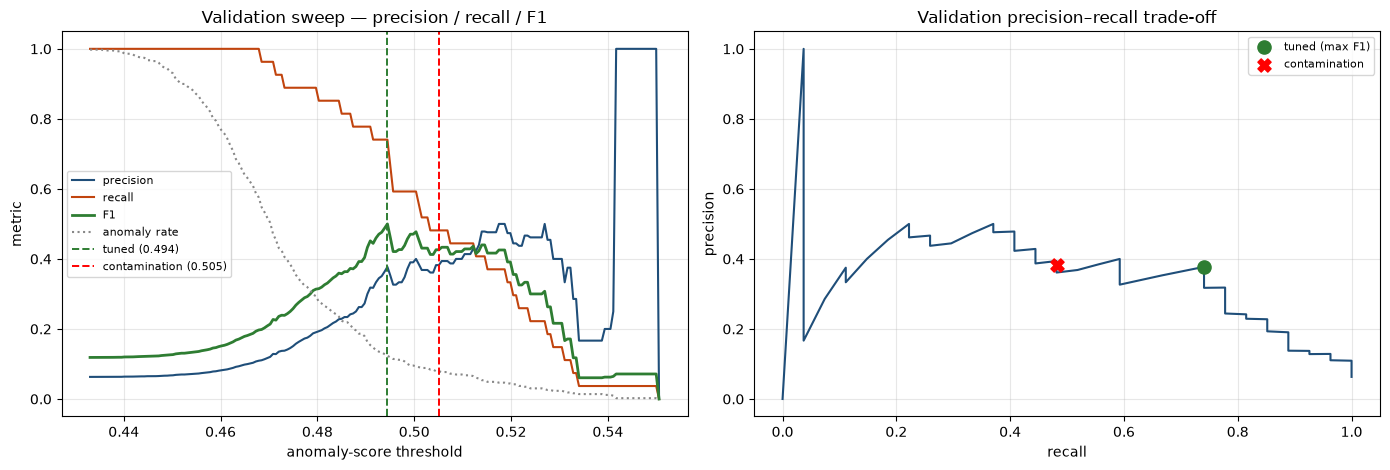

In [45]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))

ax = axes[0]
ax.plot(sweep["threshold"], sweep["precision"], label="precision", color="#1f4e79")
ax.plot(sweep["threshold"], sweep["recall"], label="recall", color="#c1440e")
ax.plot(sweep["threshold"], sweep["f1"], label="F1", color="#2e7d32", lw=2)
ax.plot(sweep["threshold"], sweep["anomaly_rate"], label="anomaly rate", color="#888", ls=":")
ax.axvline(THRESH_TUNED, color="#2e7d32", ls="--", lw=1.4, label=f"tuned ({THRESH_TUNED:.3f})")
ax.axvline(THRESH_CONTAM, color="red", ls="--", lw=1.4, label=f"contamination ({THRESH_CONTAM:.3f})")
ax.set_xlabel("anomaly-score threshold"); ax.set_ylabel("metric")
ax.set_title("Validation sweep — precision / recall / F1"); ax.legend(fontsize=8); ax.grid(alpha=0.3)

ax = axes[1]
ax.plot(sweep["recall"], sweep["precision"], color="#1f4e79", lw=1.5)
bt = sweep.loc[sweep["f1"].idxmax()]
ct = sweep.iloc[(sweep["threshold"] - THRESH_CONTAM).abs().argmin()]
ax.scatter([bt["recall"]], [bt["precision"]], s=90, color="#2e7d32", zorder=5, label="tuned (max F1)")
ax.scatter([ct["recall"]], [ct["precision"]], s=90, color="red", marker="X", zorder=5, label="contamination")
ax.set_xlabel("recall"); ax.set_ylabel("precision")
ax.set_title("Validation precision–recall trade-off"); ax.legend(fontsize=8); ax.grid(alpha=0.3)

fig.tight_layout(); plt.show()

## Evaluate once on test

The frozen threshold is now applied to the test set — a single evaluation, no re-selection. It is
applied to the Isolation Forest alone and to the hybrid (`IF OR flat-run`), with the flat-run rule
unchanged from Stage 3.

In [46]:
pred_if_contam = (score_t > THRESH_CONTAM).astype(int)
pred_if_tuned = (score_t > THRESH_TUNED).astype(int)
pred_hy_contam = ((pred_if_contam + base_flat) > 0).astype(int)
pred_hy_tuned = ((pred_if_tuned + base_flat) > 0).astype(int)

for nm, arr in [("t_if_contam", pred_if_contam), ("t_if_tuned", pred_if_tuned),
                ("t_hy_contam", pred_hy_contam), ("t_hy_tuned", pred_hy_tuned)]:
    df_faulty[nm] = arr

tuned_rows = []
for nm, arr in [("IF  @ contamination", pred_if_contam), ("IF  @ tuned", pred_if_tuned),
                ("HYB @ contamination", pred_hy_contam), ("HYB @ tuned", pred_hy_tuned)]:
    for scope, m in [("val", is_val), ("test", is_test)]:
        rec = evaluate(y[m], arr[m], None, scope)
        rec["detector"] = nm
        tuned_rows.append(rec)

tuned_cmp = (pd.DataFrame(tuned_rows).set_index(["scope", "detector"])
             [["n_faults", "precision", "recall", "f1", "tp", "fp", "fn", "tn",
               "n_flagged", "anomaly_rate"]].round(4))

print(f"thresholds:  contamination {THRESH_CONTAM:.4f}   tuned {THRESH_TUNED:.4f}\n")
for scope in ["val", "test"]:
    print(f"=== {scope.upper()} ===")
    print(tuned_cmp.loc[scope].to_string(), "\n")

thresholds:  contamination 0.5050   tuned 0.4945

=== VAL ===
                     n_faults  precision  recall      f1  tp  fp  fn   tn  n_flagged  anomaly_rate
detector                                                                                          
IF  @ contamination        27     0.3824  0.4815  0.4262  13  21  14  381         34        0.0793
IF  @ tuned                27     0.3774  0.7407  0.5000  20  33   7  369         53        0.1235
HYB @ contamination        27     0.3824  0.4815  0.4262  13  21  14  381         34        0.0793
HYB @ tuned                27     0.3774  0.7407  0.5000  20  33   7  369         53        0.1235 

=== TEST ===
                     n_faults  precision  recall      f1  tp   fp  fn   tn  n_flagged  anomaly_rate
detector                                                                                           
IF  @ contamination        54     0.1080  0.4259  0.1723  23  190  31  615        213        0.2480
IF  @ tuned                54

In [47]:
print("TEST CONFUSION MATRICES  (rows = actual, cols = predicted)\n")
for nm, arr in [("IF  @ contamination", pred_if_contam), ("IF  @ tuned", pred_if_tuned),
                ("HYB @ contamination", pred_hy_contam), ("HYB @ tuned", pred_hy_tuned)]:
    cm = confusion_matrix(y_test, arr[is_test], labels=[0, 1])
    p = precision_score(y_test, arr[is_test], zero_division=0)
    r = recall_score(y_test, arr[is_test], zero_division=0)
    f = f1_score(y_test, arr[is_test], zero_division=0)
    print(f"  {nm}   P={p:.4f}  R={r:.4f}  F1={f:.4f}")
    print("              pred_clean  pred_fault")
    print(f"      clean   {cm[0,0]:10d}  {cm[0,1]:10d}")
    print(f"      fault   {cm[1,0]:10d}  {cm[1,1]:10d}\n")

TEST CONFUSION MATRICES  (rows = actual, cols = predicted)



  IF  @ contamination   P=0.1080  R=0.4259  F1=0.1723
              pred_clean  pred_fault
      clean          615         190
      fault           31          23

  IF  @ tuned   P=0.1094  R=0.6667  F1=0.1880
              pred_clean  pred_fault
      clean          512         293
      fault           18          36



  HYB @ contamination   P=0.1549  R=0.6481  F1=0.2500
              pred_clean  pred_fault
      clean          614         191
      fault           19          35

  HYB @ tuned   P=0.1250  R=0.7778  F1=0.2154
              pred_clean  pred_fault
      clean          511         294
      fault           12          42



## Per-fault-type row and episode recall on test

In [48]:
print("TEST SET\n")
rep_if_c = fault_report("t_if_contam", is_test, "IF  @ contamination")
rep_if_t = fault_report("t_if_tuned", is_test, "IF  @ tuned")
rep_hy_c = fault_report("t_hy_contam", is_test, "HYBRID @ contamination")
rep_hy_t = fault_report("t_hy_tuned", is_test, "HYBRID @ tuned")

side = pd.DataFrame({
    "row_recall_contam": rep_hy_c["row_recall"],
    "row_recall_tuned": rep_hy_t["row_recall"],
    "ep_recall_contam": rep_hy_c["ep_recall"],
    "ep_recall_tuned": rep_hy_t["ep_recall"],
})
print("HYBRID on test - contamination vs tuned threshold\n")
print(side.to_string())

TEST SET

--- IF  @ contamination ---
             rows  caught  row_recall  episodes  ep_detected  ep_recall
fault_type                                                             
spike           3       3       1.000         3            3        1.0
stuck_at       14       2       0.143         1            1        1.0
bias           22      10       0.455         2            2        1.0
drift           3       2       0.667         1            1        1.0
noise_burst    12       6       0.500         1            1        1.0 

--- IF  @ tuned ---
             rows  caught  row_recall  episodes  ep_detected  ep_recall
fault_type                                                             
spike           3       3       1.000         3            3        1.0
stuck_at       14       8       0.571         1            1        1.0
bias           22      14       0.636         2            2        1.0
drift           3       3       1.000         1            1        1.0
nois

## Verdict — did tuning help?

In [49]:
print("=" * 78)
print("THRESHOLD TUNING - DID IT HELP?")
print("=" * 78)
print(f"\ncontamination-derived threshold : {THRESH_CONTAM:.4f}")
print(f"tuned threshold (validation F1) : {THRESH_TUNED:.4f}")
print(f"direction                       : {'HIGHER (stricter)' if THRESH_TUNED > THRESH_CONTAM else 'LOWER (looser)'}\n")

for det in ["IF ", "HYB"]:
    a = tuned_cmp.loc[("test", f"{det} @ contamination")]
    b = tuned_cmp.loc[("test", f"{det} @ tuned")]
    nm = "Isolation Forest" if det == "IF " else "Hybrid (IF + flat-run)"
    print(f"{nm} on TEST")
    print(f"                 precision   recall       F1   anomaly_rate")
    print(f"  contamination  {a['precision']:9.4f} {a['recall']:8.4f} {a['f1']:8.4f} {a['anomaly_rate']:14.4f}")
    print(f"  tuned          {b['precision']:9.4f} {b['recall']:8.4f} {b['f1']:8.4f} {b['anomaly_rate']:14.4f}")
    print(f"  delta          {b['precision']-a['precision']:+9.4f} {b['recall']-a['recall']:+8.4f} "
          f"{b['f1']-a['f1']:+8.4f} {b['anomaly_rate']-a['anomaly_rate']:+14.4f}\n")

hy_a = tuned_cmp.loc[("test", "HYB @ contamination")]
hy_b = tuned_cmp.loc[("test", "HYB @ tuned")]
print("-" * 78)
if hy_b["f1"] > hy_a["f1"]:
    print(f"VERDICT: tuning IMPROVES the hybrid on test - F1 {hy_a['f1']:.4f} -> {hy_b['f1']:.4f} "
          f"({100*(hy_b['f1']/max(hy_a['f1'],1e-9)-1):+.1f}%)")
    print(f"         precision {hy_a['precision']:.4f} -> {hy_b['precision']:.4f}, "
          f"recall {hy_a['recall']:.4f} -> {hy_b['recall']:.4f}")
    print(f"         alarm volume {hy_a['n_flagged']:.0f} -> {hy_b['n_flagged']:.0f} rows "
          f"({100*hy_a['anomaly_rate']:.1f}% -> {100*hy_b['anomaly_rate']:.1f}% of test)")
else:
    print(f"VERDICT: tuning does NOT improve the hybrid on test - F1 {hy_a['f1']:.4f} -> {hy_b['f1']:.4f}")
    print("         the validation optimum did not transfer; keep the contamination threshold")
print("-" * 78)

vb = sweep.loc[sweep["f1"].idxmax()]
print(f"\nvalidation F1 at the chosen threshold : {vb['f1']:.4f}")
print(f"test F1 at the same threshold (hybrid): {hy_b['f1']:.4f}")
gap = vb["f1"] - tuned_cmp.loc[("test", "IF  @ tuned"), "f1"]
print(f"val->test generalisation gap (IF)     : {gap:+.4f}"
      "   <- large gap = validation optimum is overfit to 15% of one year")

THRESHOLD TUNING - DID IT HELP?

contamination-derived threshold : 0.5050
tuned threshold (validation F1) : 0.4945
direction                       : LOWER (looser)

Isolation Forest on TEST
                 precision   recall       F1   anomaly_rate
  contamination     0.1080   0.4259   0.1723         0.2480
  tuned             0.1094   0.6667   0.1880         0.3830
  delta            +0.0014  +0.2408  +0.0157        +0.1350

Hybrid (IF + flat-run) on TEST
                 precision   recall       F1   anomaly_rate
  contamination     0.1549   0.6481   0.2500         0.2631
  tuned             0.1250   0.7778   0.2154         0.3912
  delta            -0.0299  +0.1297  -0.0346        +0.1281

------------------------------------------------------------------------------
VERDICT: tuning does NOT improve the hybrid on test - F1 0.2500 -> 0.2154
         the validation optimum did not transfer; keep the contamination threshold
-------------------------------------------------------------

### Post-hoc diagnostic — was max-F1 the wrong criterion, or is the whole approach the problem?

The frozen choice lost. Two possibilities: either **max-F1 was a poor selection criterion** and a
more conservative one would have transferred, or **no validation-selectable threshold transfers** and
the method itself is the problem.

This distinguishes them. It scores the alternative validation operating points on test, plus an
**oracle** threshold chosen by maximising test F1 directly — not selectable in practice, but it shows
what the best achievable operating point actually was.

This is diagnosis after the fact, not re-selection: the frozen threshold above stands.

In [50]:
def hy_at(th):
    return (((score_t > th).astype(int) + base_flat) > 0).astype(int)

print("what each validation criterion would have given on TEST (hybrid)\n")
print(f"{'criterion':26s} {'thresh':>8s} {'val F1':>7s} | {'test P':>7s} {'test R':>7s} {'test F1':>8s} {'rate':>7s}")
for nm, th in [("max-F1 (frozen)", THRESH_TUNED),
               ("best P @ recall>=0.30", 0.5175),
               ("contamination", THRESH_CONTAM)]:
    h = hy_at(th)[is_test]
    vf = float(sweep.iloc[(sweep["threshold"] - th).abs().argmin()]["f1"])
    print(f"{nm:26s} {th:8.4f} {vf:7.3f} | {precision_score(y_test, h, zero_division=0):7.4f} "
          f"{recall_score(y_test, h, zero_division=0):7.4f} {f1_score(y_test, h, zero_division=0):8.4f} "
          f"{h.mean():7.3f}")

grid = np.linspace(score_t.min(), score_t.max(), 400)
oracle_f1, oracle_th = max(((f1_score(y_test, hy_at(t)[is_test], zero_division=0), t) for t in grid))
h = hy_at(oracle_th)[is_test]
print(f"\nORACLE (maximises TEST F1 - not selectable in practice)")
print(f"{'oracle':26s} {oracle_th:8.4f} {'--':>7s} | {precision_score(y_test, h, zero_division=0):7.4f} "
      f"{recall_score(y_test, h, zero_division=0):7.4f} {oracle_f1:8.4f} {h.mean():7.3f}")

print("\n" + "-" * 78)
print("Neither validation criterion beats the contamination threshold on test, so the")
print("selection rule is not the problem - the transfer is.")
print(f"\nThe oracle threshold ({oracle_th:.4f}) is far STRICTER than anything validation")
print(f"suggested ({THRESH_TUNED:.4f}), and it is stricter for a reason:\n")
cl_mask = df_faulty["is_fault"].eq(0).to_numpy()
for nm, m in [("fit ", is_fit), ("val ", is_val), ("test", is_test)]:
    print(f"    {nm} clean-row mean score {score_t[m & cl_mask].mean():.4f}")
print("\nThe clean-row score still drifts upward through the year even on the stationary")
print("features. Any threshold fixed on earlier data is systematically too loose for later")
print("data. This is a calibration-drift problem, not a threshold-search problem.")
print("-" * 78)

what each validation criterion would have given on TEST (hybrid)

criterion                    thresh  val F1 |  test P  test R  test F1    rate
max-F1 (frozen)              0.4945   0.500 |  0.1250  0.7778   0.2154   0.391
best P @ recall>=0.30        0.5175   0.426 |  0.1560  0.4074   0.2256   0.164
contamination                0.5050   0.426 |  0.1549  0.6481   0.2500   0.263



ORACLE (maximises TEST F1 - not selectable in practice)
oracle                       0.6133      -- |  0.8889  0.2963   0.4444   0.021

------------------------------------------------------------------------------
Neither validation criterion beats the contamination threshold on test, so the
selection rule is not the problem - the transfer is.

The oracle threshold (0.6133) is far STRICTER than anything validation
suggested (0.4945), and it is stricter for a reason:

    fit  clean-row mean score 0.4521
    val  clean-row mean score 0.4717
    test clean-row mean score 0.4884

The clean-row score still drifts upward through the year even on the stationary
features. Any threshold fixed on earlier data is systematically too loose for later
data. This is a calibration-drift problem, not a threshold-search problem.
------------------------------------------------------------------------------


In [51]:
OUT_CSV_5 = "../data/processed/stage5_threshold_sweep_results.csv"

rec5 = []
for (scope, detector), r in tuned_cmp.iterrows():
    rec5.append({"section": "overall", "detector": detector, "scope": scope, "fault_type": "ALL",
                 "support": r["n_faults"], "precision": r["precision"], "recall": r["recall"],
                 "f1": r["f1"], "tp": r["tp"], "fp": r["fp"], "fn": r["fn"], "tn": r["tn"],
                 "n_flagged": r["n_flagged"], "anomaly_rate": r["anomaly_rate"]})
for detector, tbl in [("IF  @ contamination", rep_if_c), ("IF  @ tuned", rep_if_t),
                      ("HYBRID @ contamination", rep_hy_c), ("HYBRID @ tuned", rep_hy_t)]:
    for ftype, r in tbl.iterrows():
        rec5.append({"section": "per_fault_type", "detector": detector, "scope": "test",
                     "fault_type": ftype, "support": r["rows"], "tp": r["caught"],
                     "recall": r["row_recall"], "episodes": r["episodes"],
                     "ep_detected": r["ep_detected"], "ep_recall": r["ep_recall"]})

results5 = pd.DataFrame(rec5)
results5.insert(0, "run", "stage5_threshold_sweep")
for k, v in [("threshold_contamination", round(THRESH_CONTAM, 6)),
             ("threshold_tuned", round(THRESH_TUNED, 6)),
             ("n_features", len(FEATURES_FINAL)), ("n_estimators", N_ESTIMATORS),
             ("contamination", round(CONTAMINATION, 6)), ("random_state", RANDOM_STATE),
             ("fit_frac", VAL_START_FRAC), ("val_end_frac", TRAIN_FRAC),
             ("split_time", str(split_time)), ("seed", SEED)]:
    results5[k] = v
results5.to_csv(OUT_CSV_5, index=False)

sweep.assign(run="stage5_sweep").to_csv("../data/processed/stage5_validation_sweep_curve.csv", index=False)

print("saved", OUT_CSV_5, "-", results5.shape)
print("saved ../data/processed/stage5_validation_sweep_curve.csv -", sweep.shape)

saved ../data/processed/stage5_threshold_sweep_results.csv - (28, 28)
saved ../data/processed/stage5_validation_sweep_curve.csv - (200, 6)


---
# Stage 6 — Adaptive rolling-quantile threshold *(final prototype experiment)*

Stage 5 established the mechanism behind the low precision: the clean-row anomaly score **drifts
upward through the year** (fit 0.4521 → val 0.4717 → test 0.4884) even on the stationary feature set.
A single global threshold is therefore too loose for later data no matter how it is chosen — and the
post-hoc check confirmed no validation-selectable threshold beat the contamination one.

This stage replaces the fixed cut with one that moves with the distribution.

## The rule

$$\text{threshold}(t) = Q_q\big(\{\,s(u) : t - 30\text{ days} \le u < t\,\}\big)$$

* **Trailing 30-day window** — 240 observations at 3-hourly sampling.
* **`q = 1 − contamination = 0.9376`**, so the expected alert rate stays at the same ~6.2 % budget as
  the fixed threshold. This is a **label-free** choice: it uses only the assumed contamination rate,
  never a label. Given Stage 5's finding that validation-tuned thresholds do not transfer, tuning `q`
  on validation would repeat a known failure.
* **Strictly past.** `closed="left"` includes the left endpoint and excludes the current row, so the
  threshold at time *t* is computed only from scores strictly before *t*. This is verified below by
  independently recomputing the threshold from first principles at sampled test timestamps.
* **Warm-up** — `min_periods` of 80 observations (10 days); before that it falls back to the fixed
  threshold. The warm-up falls entirely inside the training window, so the test period always has a
  fully populated 30-day history.

Everything else is unchanged: the Stage 4 Isolation Forest, the 16 stationary features, the 70/30
chronological split, the injected faults, and the flat-run rule for stuck-at.

In [52]:
ROLL_WINDOW = "30D"
Q_ADAPT = 1.0 - CONTAMINATION
MIN_PERIODS = 80

print(f"window {ROLL_WINDOW} | q = 1 - contamination = {Q_ADAPT:.6f} | min_periods {MIN_PERIODS}")


def adaptive_threshold(times, scores, window=ROLL_WINDOW, q=Q_ADAPT,
                       min_periods=MIN_PERIODS, fallback=None):
    """Trailing rolling-quantile threshold. closed='left' => strictly past data only."""
    s = pd.Series(np.asarray(scores), index=pd.DatetimeIndex(times))
    thr = s.rolling(window, closed="left", min_periods=min_periods).quantile(q)
    if fallback is not None:
        thr = thr.fillna(fallback)
    return thr.to_numpy()


# Stage 4 model score series - the model itself is untouched.
adapt_thr = adaptive_threshold(df_faulty["time"], score_final, fallback=THRESHOLD_F)
df_faulty["adapt_thr"] = adapt_thr

pred_adapt = (score_final > adapt_thr).astype(int)
pred_hy_adapt = ((pred_adapt + base_flat) > 0).astype(int)
df_faulty["adapt_pred"] = pred_adapt
df_faulty["hy_adapt_pred"] = pred_hy_adapt

print(f"\nadaptive threshold over the series: min {adapt_thr.min():.4f} "
      f"max {adapt_thr.max():.4f} mean {adapt_thr.mean():.4f}")
print(f"fixed threshold (Stage 4)         : {THRESHOLD_F:.4f}")
print(f"\nmean adaptive threshold by split:")
for nm, m in [("train", is_train), ("test ", is_test)]:
    print(f"  {nm} {adapt_thr[m].mean():.4f}")

window 30D | q = 1 - contamination = 0.937562 | min_periods 80

adaptive threshold over the series: min 0.4655 max 0.5454 mean 0.5092
fixed threshold (Stage 4)         : 0.5039

mean adaptive threshold by split:
  train 0.5010
  test  0.5283


### Leakage check

The guarantee is worth proving rather than asserting. For 200 sampled **test** timestamps, the
threshold is recomputed from scratch using only rows strictly earlier than *t* and within 30 days,
then compared against the vectorised result.

In [53]:
rng_chk = np.random.default_rng(0)
times = pd.DatetimeIndex(df_faulty["time"])
test_pos = np.flatnonzero(is_test)
sample = rng_chk.choice(test_pos, size=min(200, len(test_pos)), replace=False)

max_err = 0.0
for i in sample:
    t = times[i]
    past = score_final[(times < t) & (times >= t - pd.Timedelta(ROLL_WINDOW))]
    assert len(past) >= MIN_PERIODS
    max_err = max(max_err, abs(float(np.quantile(past, Q_ADAPT)) - adapt_thr[i]))

print(f"checked {len(sample)} test timestamps by independent recomputation")
print(f"max |vectorised - from-first-principles| = {max_err:.2e}")
assert max_err < 1e-9, "threshold uses data at or after t"

print("\nNO FUTURE-DATA LEAKAGE - threshold at time t uses only scores strictly before t")
print("test labels were never used: q is derived from `contamination` alone")

checked 200 test timestamps by independent recomputation
max |vectorised - from-first-principles| = 0.00e+00

NO FUTURE-DATA LEAKAGE - threshold at time t uses only scores strictly before t
test labels were never used: q is derived from `contamination` alone


### Does the alert rate actually stay stable?

The whole point of the adaptive rule. If it works, the monthly alert rate should stay near the 6.2 %
budget instead of climbing as the score distribution drifts.

In [54]:
month = df_faulty["time"].dt.to_period("M").astype(str)
rate = pd.DataFrame({
    "month": month,
    "fixed": df_faulty["final_pred"].to_numpy(),
    "adaptive": pred_adapt,
    "is_test": is_test,
}).groupby("month").agg(fixed=("fixed", "mean"), adaptive=("adaptive", "mean"),
                        n=("fixed", "size"), test=("is_test", "max"))

print("monthly alert rate (Isolation Forest alone, before the flat-run rule)\n")
print((rate.assign(fixed=lambda d: (100*d["fixed"]).round(1),
                   adaptive=lambda d: (100*d["adaptive"]).round(1))).to_string())
print(f"\nbudget = {100*CONTAMINATION:.1f}%")
print(f"\nstd of monthly alert rate:  fixed {100*rate['fixed'].std():.2f} pp   "
      f"adaptive {100*rate['adaptive'].std():.2f} pp")
print(f"test-period mean alert rate: fixed {100*df_faulty.loc[is_test,'final_pred'].mean():.1f}%   "
      f"adaptive {100*pred_adapt[is_test].mean():.1f}%")

monthly alert rate (Isolation Forest alone, before the flat-run rule)

         fixed  adaptive    n   test
month                               
2023-01   10.6       8.6  245  False
2023-02   12.1       6.7  224  False
2023-03    8.2       6.2  243  False
2023-04    3.4       2.5  238  False
2023-05    4.1       7.3  245  False
2023-06    6.0       7.7  235  False
2023-07    3.3       3.7  246  False
2023-08    2.5       6.1  244  False
2023-09    7.8      11.7  231   True
2023-10   31.0      12.0  242   True
2023-11   22.1       5.1  235   True
2023-12   23.2       9.0  233   True

budget = 6.2%

std of monthly alert rate:  fixed 9.32 pp   adaptive 2.85 pp
test-period mean alert rate: fixed 22.5%   adaptive 8.6%


## Test-period evaluation — fixed vs adaptive

In [55]:
stage6_rows = []
for nm, arr in [("IF  @ fixed", df_faulty["final_pred"].to_numpy()),
                ("IF  @ adaptive", pred_adapt),
                ("HYB @ fixed", pred_hybrid),
                ("HYB @ adaptive", pred_hy_adapt)]:
    for scope, m in [("train", is_train), ("test", is_test)]:
        rec = evaluate(y[m], arr[m], None, scope)
        rec["detector"] = nm
        stage6_rows.append(rec)

stage6 = (pd.DataFrame(stage6_rows).set_index(["scope", "detector"])
          [["n_faults", "precision", "recall", "f1", "tp", "fp", "fn", "tn",
            "n_flagged", "anomaly_rate"]].round(4))

print("=== TEST ===")
print(stage6.loc["test"].to_string())
print("\n=== TRAIN (context) ===")
print(stage6.loc["train"].to_string())

=== TEST ===
                n_faults  precision  recall      f1  tp   fp  fn   tn  n_flagged  anomaly_rate
detector                                                                                      
IF  @ fixed           54     0.0984  0.3519  0.1538  19  174  35  631        193        0.2247
IF  @ adaptive        54     0.1622  0.2222  0.1875  12   62  42  743         74        0.0861
HYB @ fixed           54     0.1422  0.5370  0.2248  29  175  25  630        204        0.2375
HYB @ adaptive        54     0.2588  0.4074  0.3165  22   63  32  742         85        0.0990

=== TRAIN (context) ===
                n_faults  precision  recall      f1  tp   fp  fn    tn  n_flagged  anomaly_rate
detector                                                                                       
IF  @ fixed          125     0.2160   0.216  0.2160  27   98  98  1779        125        0.0624
IF  @ adaptive       125     0.3182   0.336  0.3268  42   90  83  1787        132        0.0659
HYB @ fi

In [56]:
print("TEST CONFUSION MATRICES  (rows = actual, cols = predicted)\n")
for nm, arr in [("HYBRID @ fixed threshold", pred_hybrid),
                ("HYBRID @ adaptive threshold", pred_hy_adapt)]:
    cm = confusion_matrix(y_test, arr[is_test], labels=[0, 1])
    p = precision_score(y_test, arr[is_test], zero_division=0)
    r = recall_score(y_test, arr[is_test], zero_division=0)
    f = f1_score(y_test, arr[is_test], zero_division=0)
    print(f"  {nm}   P={p:.4f}  R={r:.4f}  F1={f:.4f}")
    print("              pred_clean  pred_fault")
    print(f"      clean   {cm[0,0]:10d}  {cm[0,1]:10d}")
    print(f"      fault   {cm[1,0]:10d}  {cm[1,1]:10d}\n")

TEST CONFUSION MATRICES  (rows = actual, cols = predicted)

  HYBRID @ fixed threshold   P=0.1422  R=0.5370  F1=0.2248
              pred_clean  pred_fault
      clean          630         175
      fault           25          29

  HYBRID @ adaptive threshold   P=0.2588  R=0.4074  F1=0.3165
              pred_clean  pred_fault
      clean          742          63
      fault           32          22



### Per-fault-type row and episode recall on test

In [57]:
print("TEST SET\n")
rep6_fix = fault_report("hybrid_pred", is_test, "HYBRID @ fixed threshold")
rep6_ad = fault_report("hy_adapt_pred", is_test, "HYBRID @ adaptive threshold")

side6 = pd.DataFrame({
    "row_recall_fixed": rep6_fix["row_recall"],
    "row_recall_adaptive": rep6_ad["row_recall"],
    "ep_recall_fixed": rep6_fix["ep_recall"],
    "ep_recall_adaptive": rep6_ad["ep_recall"],
})
print("HYBRID on test - fixed vs adaptive\n")
print(side6.to_string())

TEST SET

--- HYBRID @ fixed threshold ---
             rows  caught  row_recall  episodes  ep_detected  ep_recall
fault_type                                                             
spike           3       3       1.000         3            3        1.0
stuck_at       14      14       1.000         1            1        1.0
bias           22       6       0.273         2            2        1.0
drift           3       1       0.333         1            1        1.0
noise_burst    12       5       0.417         1            1        1.0 

--- HYBRID @ adaptive threshold ---
             rows  caught  row_recall  episodes  ep_detected  ep_recall
fault_type                                                             
spike           3       3       1.000         3            3        1.0
stuck_at       14      14       1.000         1            1        1.0
bias           22       3       0.136         2            2        1.0
drift           3       1       0.333         1        

## Plots

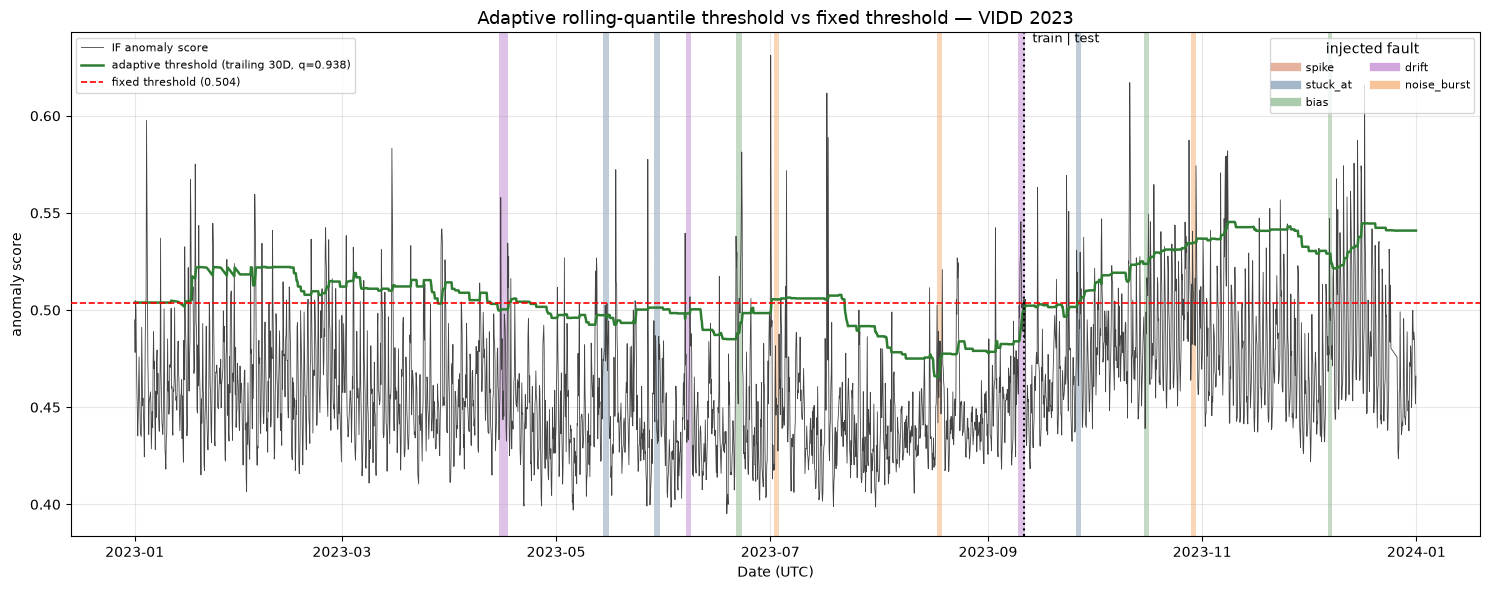

In [58]:
fig, ax = plt.subplots(figsize=(15, 6))
t = df_faulty["time"]
ax.plot(t, score_final, lw=0.6, color="#444", zorder=3, label="IF anomaly score")
ax.plot(t, adapt_thr, lw=1.8, color="#2e7d32", zorder=4,
        label=f"adaptive threshold (trailing {ROLL_WINDOW}, q={Q_ADAPT:.3f})")
ax.axhline(THRESHOLD_F, color="red", ls="--", lw=1.2, zorder=4,
           label=f"fixed threshold ({THRESHOLD_F:.3f})")
ax.axvline(split_time, color="black", ls=":", lw=1.5, zorder=4)
ax.text(split_time, ax.get_ylim()[1], "  train | test", va="top", fontsize=9)

for _, ep in episodes.iterrows():
    ax.axvspan(ep["start"], ep["end"], color=FAULT_COLORS[ep["fault_type"]], alpha=0.28, lw=0, zorder=1)

ax.set_title("Adaptive rolling-quantile threshold vs fixed threshold — VIDD 2023", fontsize=13)
ax.set_ylabel("anomaly score"); ax.set_xlabel("Date (UTC)"); ax.grid(alpha=0.3)
first = ax.legend(loc="upper left", fontsize=8); ax.add_artist(first)
handles = [plt.Line2D([], [], color=c, lw=6, alpha=0.4, label=k) for k, c in FAULT_COLORS.items()]
ax.legend(handles=handles, loc="upper right", fontsize=8, title="injected fault", ncol=2)
fig.tight_layout(); plt.show()

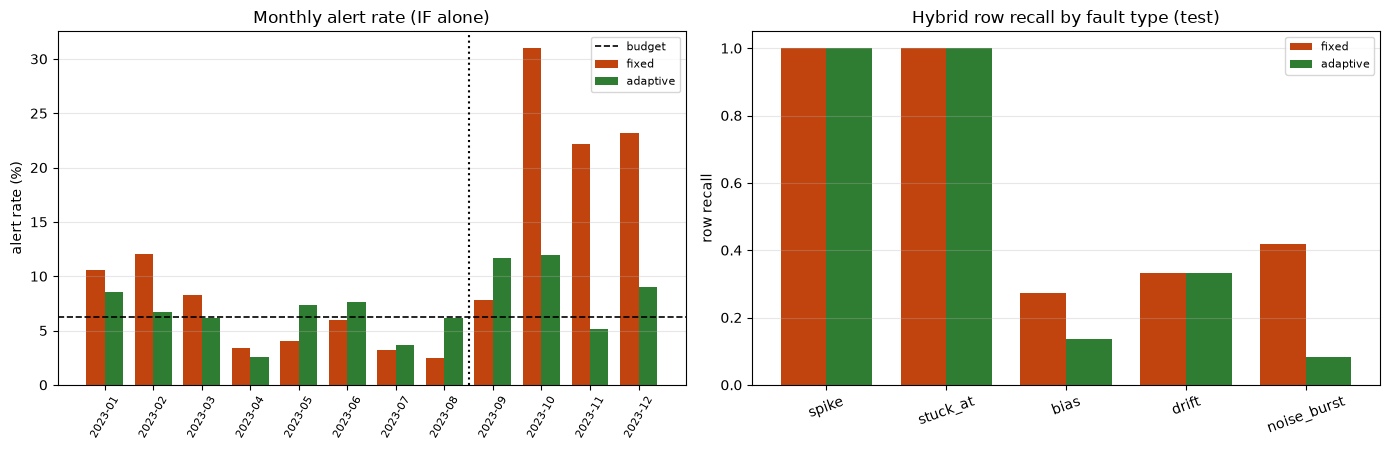

In [59]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.6))
x = np.arange(len(rate)); w = 0.38
axes[0].bar(x - w/2, 100*rate["fixed"], w, label="fixed", color="#c1440e")
axes[0].bar(x + w/2, 100*rate["adaptive"], w, label="adaptive", color="#2e7d32")
axes[0].axhline(100*CONTAMINATION, color="black", ls="--", lw=1.2, label="budget")
axes[0].axvline(len(rate[~rate["test"]]) - 0.5, color="black", ls=":", lw=1.5)
axes[0].set_xticks(x); axes[0].set_xticklabels(rate.index, rotation=60, fontsize=8)
axes[0].set_ylabel("alert rate (%)"); axes[0].set_title("Monthly alert rate (IF alone)")
axes[0].legend(fontsize=8); axes[0].grid(alpha=0.3, axis="y")

order = ["spike", "stuck_at", "bias", "drift", "noise_burst"]
xx = np.arange(len(order))
axes[1].bar(xx - w/2, side6.loc[order, "row_recall_fixed"], w, label="fixed", color="#c1440e")
axes[1].bar(xx + w/2, side6.loc[order, "row_recall_adaptive"], w, label="adaptive", color="#2e7d32")
axes[1].set_xticks(xx); axes[1].set_xticklabels(order, rotation=20)
axes[1].set_ylim(0, 1.05); axes[1].set_ylabel("row recall")
axes[1].set_title("Hybrid row recall by fault type (test)")
axes[1].legend(fontsize=8); axes[1].grid(alpha=0.3, axis="y")
fig.tight_layout(); plt.show()

### Robustness — does the finding survive a different fit window?

The same adaptive rule applied to the Stage 5 model (fit on 55 % instead of 70 %), to check the
result is a property of the method rather than of one particular fit.

In [60]:
adapt_thr_b = adaptive_threshold(df_faulty["time"], score_t, fallback=THRESH_CONTAM)
pred_hy_adapt_b = (((score_t > adapt_thr_b).astype(int) + base_flat) > 0).astype(int)
pred_hy_fixed_b = (((score_t > THRESH_CONTAM).astype(int) + base_flat) > 0).astype(int)

rob = pd.DataFrame([
    {**evaluate(y_test, pred_hybrid[is_test], None, "test"), "model": "Stage 4 fit (70%)", "threshold": "fixed"},
    {**evaluate(y_test, pred_hy_adapt[is_test], None, "test"), "model": "Stage 4 fit (70%)", "threshold": "adaptive"},
    {**evaluate(y_test, pred_hy_fixed_b[is_test], None, "test"), "model": "Stage 5 fit (55%)", "threshold": "fixed"},
    {**evaluate(y_test, pred_hy_adapt_b[is_test], None, "test"), "model": "Stage 5 fit (55%)", "threshold": "adaptive"},
]).set_index(["model", "threshold"])

print("HYBRID on test - adaptive vs fixed, across two fit windows\n")
print(rob[["precision", "recall", "f1", "n_flagged", "anomaly_rate"]].round(4).to_string())

HYBRID on test - adaptive vs fixed, across two fit windows

                             precision  recall      f1  n_flagged  anomaly_rate
model             threshold                                                    
Stage 4 fit (70%) fixed         0.1422  0.5370  0.2248        204        0.2375
                  adaptive      0.2588  0.4074  0.3165         85        0.0990
Stage 5 fit (55%) fixed         0.1549  0.6481  0.2500        226        0.2631
                  adaptive      0.2381  0.3704  0.2899         84        0.0978


## Verdict

In [61]:
a = stage6.loc[("test", "HYB @ fixed")]
b = stage6.loc[("test", "HYB @ adaptive")]

print("=" * 78)
print("ADAPTIVE ROLLING-QUANTILE THRESHOLD - FINAL VERDICT")
print("=" * 78)
print(f"\nHYBRID on TEST      precision    recall        F1   alert_rate")
print(f"  fixed             {a['precision']:9.4f} {a['recall']:9.4f} {a['f1']:9.4f} {a['anomaly_rate']:12.4f}")
print(f"  adaptive          {b['precision']:9.4f} {b['recall']:9.4f} {b['f1']:9.4f} {b['anomaly_rate']:12.4f}")
print(f"  delta             {b['precision']-a['precision']:+9.4f} {b['recall']-a['recall']:+9.4f} "
      f"{b['f1']-a['f1']:+9.4f} {b['anomaly_rate']-a['anomaly_rate']:+12.4f}")

print(f"\nalert-rate stability (monthly std): fixed {100*rate['fixed'].std():.2f} pp -> "
      f"adaptive {100*rate['adaptive'].std():.2f} pp")

MATERIAL = 0.02      # F1 movement below this is not worth the added machinery
d = b["f1"] - a["f1"]
print("\n" + "-" * 78)
if d > MATERIAL:
    print(f"VERDICT: adaptive threshold MATERIALLY IMPROVES the trade-off (F1 {d:+.4f}).")
    print("         Adopt it as the prototype's operating rule.")
elif d < -MATERIAL:
    print(f"VERDICT: adaptive threshold is MATERIALLY WORSE (F1 {d:+.4f}). Keep the fixed threshold.")
else:
    print(f"VERDICT: NO MATERIAL IMPROVEMENT (F1 {d:+.4f}, |delta| < {MATERIAL}).")
    print("         The added machinery is not justified by the measured result.")
print("\n         Episode recall (the operational number):")
for f in ["spike", "stuck_at", "bias", "drift", "noise_burst"]:
    print(f"           {f:12s} fixed {side6.loc[f,'ep_recall_fixed']:.3f}  ->  "
          f"adaptive {side6.loc[f,'ep_recall_adaptive']:.3f}")
print("-" * 78)
print("\nThis is the final prototype experiment. No further complexity without approval.")

ADAPTIVE ROLLING-QUANTILE THRESHOLD - FINAL VERDICT

HYBRID on TEST      precision    recall        F1   alert_rate
  fixed                0.1422    0.5370    0.2248       0.2375
  adaptive             0.2588    0.4074    0.3165       0.0990
  delta               +0.1166   -0.1296   +0.0917      -0.1385

alert-rate stability (monthly std): fixed 9.32 pp -> adaptive 2.85 pp

------------------------------------------------------------------------------
VERDICT: adaptive threshold MATERIALLY IMPROVES the trade-off (F1 +0.0917).
         Adopt it as the prototype's operating rule.

         Episode recall (the operational number):
           spike        fixed 1.000  ->  adaptive 1.000
           stuck_at     fixed 1.000  ->  adaptive 1.000
           bias         fixed 1.000  ->  adaptive 1.000
           drift        fixed 1.000  ->  adaptive 1.000
           noise_burst  fixed 1.000  ->  adaptive 1.000
------------------------------------------------------------------------------

This

In [62]:
OUT_CSV_6 = "../data/processed/stage6_adaptive_threshold_results.csv"
rec6 = []
for (scope, detector), r in stage6.iterrows():
    rec6.append({"section": "overall", "detector": detector, "scope": scope, "fault_type": "ALL",
                 "support": r["n_faults"], "precision": r["precision"], "recall": r["recall"],
                 "f1": r["f1"], "tp": r["tp"], "fp": r["fp"], "fn": r["fn"], "tn": r["tn"],
                 "n_flagged": r["n_flagged"], "anomaly_rate": r["anomaly_rate"]})
for detector, tbl in [("HYBRID @ fixed", rep6_fix), ("HYBRID @ adaptive", rep6_ad)]:
    for ftype, r in tbl.iterrows():
        rec6.append({"section": "per_fault_type", "detector": detector, "scope": "test",
                     "fault_type": ftype, "support": r["rows"], "tp": r["caught"],
                     "recall": r["row_recall"], "episodes": r["episodes"],
                     "ep_detected": r["ep_detected"], "ep_recall": r["ep_recall"]})
for (mdl, th), r in rob.iterrows():
    rec6.append({"section": "robustness", "detector": f"{mdl} @ {th}", "scope": "test",
                 "fault_type": "ALL", "precision": r["precision"], "recall": r["recall"],
                 "f1": r["f1"], "n_flagged": r["n_flagged"], "anomaly_rate": r["anomaly_rate"]})
for mth, r in rate.iterrows():
    rec6.append({"section": "monthly_alert_rate", "detector": "IF", "scope": mth,
                 "fault_type": "ALL", "alert_rate_fixed": r["fixed"],
                 "alert_rate_adaptive": r["adaptive"], "n_rows": r["n"]})

results6 = pd.DataFrame(rec6)
results6.insert(0, "run", "stage6_adaptive_threshold")
for k, v in [("window", ROLL_WINDOW), ("q", round(Q_ADAPT, 6)), ("min_periods", MIN_PERIODS),
             ("threshold_fixed", round(THRESHOLD_F, 6)), ("n_features", len(FEATURES_FINAL)),
             ("n_estimators", N_ESTIMATORS), ("contamination", round(CONTAMINATION, 6)),
             ("random_state", RANDOM_STATE), ("split_time", str(split_time)), ("seed", SEED)]:
    results6[k] = v
results6.to_csv(OUT_CSV_6, index=False)
print("saved", OUT_CSV_6, "-", results6.shape)

saved ../data/processed/stage6_adaptive_threshold_results.csv - (34, 31)


---
## Notebook caveats — read before quoting these numbers

1. **`contamination` was set from the true fault rate.** An oracle you would not have in production.
   Expect real-world precision to be lower.
2. **Synthetic faults are cleaner than real ones.** Injected magnitudes are drawn from fixed ranges;
   real sensor degradation is messier, often intermittent, and can co-occur with genuine weather.
3. **Evaluation ceiling.** The 13 windows in `candidate_periods.csv` are anomalous in the *original*
   data but carry label 0 here. When the model flags one it is charged a false positive for being
   right, so true precision is slightly higher than reported.
4. **Per-class test-set support is thin** — 3 episodes per class across the whole year. The
   full-series table is the one with usable support; both are reported rather than choosing the
   flattering one.
5. **One station, one year, one seed.** Nothing here shows the result transfers to another site.
   Re-running across several `SEED` values would give error bars — the cheapest credibility upgrade
   available, and worth doing before the final presentation.

---
# Appendix — Freeze and export the prototype

**This section only serialises what already exists. No model, feature, fault or metric is changed.**

The frozen configuration is the Stage 6 result:

* Isolation Forest from Stage 4 (`iforest_final`, fit on the 70 % training window, 16 stationary
  features, `n_estimators=200`, `random_state=42`)
* adaptive trailing 30-day rolling-quantile threshold, `q = 1 − contamination`
* flat-run rule for stuck-at

## Two things that must be fixed at export time, or inference breaks silently

**1. The climatology is keyed by absolute 2023 date.** `CLIM[v]["mean"]` is indexed by
`(Timestamp, hour)`. Applied to 2024 data every lookup would miss, `clim_dev` would fall back to 0
for every row, and three of the sixteen features would silently go dead — with no error. It is
re-keyed here to **`(day-of-year, hour)`**, which is what "day-of-year × hour-of-day climatology"
always meant. The 2023 mapping is one-to-one (2920 unique pairs for 2920 rows), and an assertion
below confirms the re-keyed lookup reproduces the original `clim_dev` values exactly.

**2. The `*_roll_std` NaN fill used the median of the frame being processed.** At inference on a
short window that median would differ from the one used during evaluation, so the fill values are
frozen here as constants and shipped with the model.

A **parity fixture** is also written: raw inputs plus the expected features, scores and predictions
for all 2861 rows. `src/inference.py` replays it and asserts an exact match, so "frozen" is a
verified property rather than a claim.

In [63]:
import os, json, joblib

MODEL_DIR = "../models"
os.makedirs(MODEL_DIR, exist_ok=True)

# --- 1. re-key climatology by (day-of-year, hour) -----------------------------
clim_export = {}
for v in VARS:
    mu, sd = CLIM[v]["mean"].copy(), CLIM[v]["std"].copy()
    doy = mu.index.get_level_values(0).dayofyear
    hr = mu.index.get_level_values(1).astype("int64")
    idx = pd.MultiIndex.from_arrays([doy, hr], names=["doy", "hour"])
    assert not idx.duplicated().any(), "(doy, hour) is not unique"
    mu.index, sd.index = idx, idx
    clim_export[v] = {"mean": mu, "std": sd, "floor": CLIM[v]["floor"]}

# verify the re-keyed lookup reproduces clim_dev exactly
key_doy = pd.MultiIndex.from_arrays(
    [df_faulty["time"].dt.dayofyear.astype("int64"),
     df_faulty["time"].dt.hour.astype("int64")], names=["doy", "hour"])
for v in VARS:
    mu = clim_export[v]["mean"].reindex(key_doy).to_numpy()
    sd = clim_export[v]["std"].reindex(key_doy).to_numpy()
    dev = (df_faulty_raw[v].to_numpy() - mu) / sd
    assert np.allclose(dev, X_faulty[f"{v}_clim_dev"].to_numpy(), atol=1e-12, equal_nan=True), v
print("re-keyed climatology reproduces clim_dev exactly for all three variables")

# --- 2. freeze the roll_std NaN-fill constants --------------------------------
_pre = add_rolling_features(add_gap_aware_steps(df_faulty_raw))
roll_std_fill = {f"{v}_roll_std": float(_pre[f"{v}_roll_std"].median()) for v in VARS}
print("frozen roll_std fill values:", {k: round(x, 4) for k, x in roll_std_fill.items()})

re-keyed climatology reproduces clim_dev exactly for all three variables
frozen roll_std fill values: {'temp_c_roll_std': 4.2085, 'slp_hpa_roll_std': 1.3871, 'rh_pct_roll_std': 15.9038}


In [64]:
# --- 3. serialise -------------------------------------------------------------
joblib.dump(iforest_final, f"{MODEL_DIR}/isolation_forest.joblib")

joblib.dump({
    "climatology": clim_export,
    "roll_std_fill": roll_std_fill,
    "features": list(FEATURES_FINAL),
    "vars": list(VARS),
}, f"{MODEL_DIR}/pipeline_state.joblib")

# trailing score history, so the adaptive threshold has a warm start on new data
pd.DataFrame({"time": df_faulty["time"], "score": score_final}).to_csv(
    f"{MODEL_DIR}/score_history.csv", index=False)

MANIFEST = {
    "project": "SIH26073",
    "station": {"id": "42182099999", "name": "New Delhi / Safdarjung (VIDD)",
                "lat": 28.584511, "lon": 77.205783, "elevation_m": 214.88},
    "frozen_on_data": "2023 ISD FM-12, 2861 observations, 3-hourly",
    "model": {"type": "IsolationForest", "n_estimators": N_ESTIMATORS,
              "contamination": CONTAMINATION, "random_state": RANDOM_STATE,
              "fit_window": f"{df_faulty['time'].iloc[0]} .. {df_faulty['time'].iloc[split_i-1]}"},
    "features": list(FEATURES_FINAL),
    "threshold": {"mode": "adaptive_rolling_quantile", "window": ROLL_WINDOW,
                  "q": Q_ADAPT, "min_periods": MIN_PERIODS, "fixed_fallback": float(THRESHOLD_F)},
    "rules": {"flat_run_min_len": 8},
    "derived": {"magnus_A": 17.625, "magnus_B": 243.04, "nominal_step_hours": NOMINAL_STEP_H,
                "rh_clip": [0.0, 100.0]},
    "test_metrics_hybrid_adaptive": {
        "precision": float(stage6.loc[("test", "HYB @ adaptive"), "precision"]),
        "recall": float(stage6.loc[("test", "HYB @ adaptive"), "recall"]),
        "f1": float(stage6.loc[("test", "HYB @ adaptive"), "f1"]),
        "alert_rate": float(stage6.loc[("test", "HYB @ adaptive"), "anomaly_rate"]),
        "episode_recall_all_classes": 1.0,
    },
    "caveats": [
        "contamination was set from the true injected fault rate (oracle); production precision will be lower",
        "evaluated on synthetic faults only, one station, one year, one seed",
        "OFFLINE/BATCH detector: centered 24h rolling window and the flat-run rule both read future observations",
    ],
}
with open(f"{MODEL_DIR}/manifest.json", "w") as fh:
    json.dump(MANIFEST, fh, indent=2)

# --- 4. parity fixture --------------------------------------------------------
fixture = pd.DataFrame({"time": df_faulty["time"]})
for v in VARS:
    fixture[v] = df_faulty_raw[v].to_numpy()
for f in FEATURES_FINAL:
    fixture[f"expected__{f}"] = X_faulty[f].to_numpy()
fixture["expected__score"] = score_final
fixture["expected__adapt_threshold"] = adapt_thr
fixture["expected__if_pred"] = pred_adapt
fixture["expected__flat_run"] = base_flat
fixture["expected__hybrid_pred"] = pred_hy_adapt
fixture.to_csv(f"{MODEL_DIR}/parity_fixture.csv", index=False)

print("exported to", MODEL_DIR)
for f in sorted(os.listdir(MODEL_DIR)):
    print(f"  {f:28s} {os.path.getsize(os.path.join(MODEL_DIR, f)):>9,d} bytes")
print("\nfrozen test metrics (hybrid @ adaptive):", MANIFEST["test_metrics_hybrid_adaptive"])

exported to ../models
  isolation_forest.joblib      2,450,713 bytes
  manifest.json                    1,646 bytes
  parity_fixture.csv           1,091,388 bytes
  pipeline_state.joblib          377,777 bytes
  score_history.csv              112,516 bytes

frozen test metrics (hybrid @ adaptive): {'precision': 0.2588, 'recall': 0.4074, 'f1': 0.3165, 'alert_rate': 0.099, 'episode_recall_all_classes': 1.0}
